# Nifty50 Point Forecasting using RNN
## Deep Learning Time Series Forecasting with Comprehensive Analysis

**Objective**: Predict next-day percentage change in Nifty50 using SimpleRNN architecture with systematic hyperparameter tuning and evaluation metrics.

**Research Foundation**: Based on methodologies from:
- "Deep Learning for Stock Market Prediction" (Fischer & Krauss, 2018)
- "Recurrent Neural Networks for Time Series Forecasting" (Hewamalage et al., 2021)
- "Time Series Forecasting using Recurrent Neural Networks" (Bengio et al., 1994)

In [2]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.21.0
GPU Available: []


## 1. Data Loading and Exploration

In [3]:
# Load dataset
df = pd.read_csv('../nifty_final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")
print(f"Total Trading Days: {len(df)}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum().sum()}")

# Display basic statistics
print("\n" + "="*80)
print("TARGET VARIABLE STATISTICS")
print("="*80)
print(df['target'].describe())

df.head(10)

DATASET OVERVIEW
Dataset Shape: (1848, 84)
Date Range: 2018-01-30 00:00:00 to 2026-03-27 00:00:00
Total Trading Days: 1848

Columns (84): ['close', 'high', 'low', 'open', 'volume', 'log_ret', 'ret_1', 'ret_5', 'ret_15', 'vol_5', 'vol_15', 'body', 'range', 'upper_wick', 'lower_wick', 'close_pos', 'ma_5', 'ma_20', 'dist_ma_5', 'dist_ma_20', 'volume_ma_5', 'volume_spike', 'target', 'bank_ret', 'it_ret', 'pharma_ret', 'auto_ret', 'fmcg_ret', 'metal_ret', 'energy_ret', 'log_ret_lag1', 'log_ret_lag2', 'bank_ret_lag1', 'bank_ret_lag2', 'it_ret_lag1', 'it_ret_lag2', 'pharma_ret_lag1', 'pharma_ret_lag2', 'auto_ret_lag1', 'auto_ret_lag2', 'fmcg_ret_lag1', 'fmcg_ret_lag2', 'metal_ret_lag1', 'metal_ret_lag2', 'energy_ret_lag1', 'energy_ret_lag2', 'corr_nifty_log_ret', 'corr_nifty_bank_ret', 'corr_nifty_it_ret', 'corr_nifty_pharma_ret', 'corr_nifty_auto_ret', 'corr_nifty_fmcg_ret', 'corr_nifty_metal_ret', 'corr_nifty_energy_ret', 'corr_nifty_log_ret_lag1', 'corr_nifty_log_ret_lag2', 'corr_nifty_ban

,close,high,low,open,volume,log_ret,ret_1,ret_5,ret_15,vol_5,...,sector_mean,sector_std,strongest_sector,bank_ret_vs_nifty,it_ret_vs_nifty,pharma_ret_vs_nifty,auto_ret_vs_nifty,fmcg_ret_vs_nifty,metal_ret_vs_nifty,energy_ret_vs_nifty
date,,,,,,,,,,,,,,,,,,,,,
2018-01-30,11049.650391,11121.099609,11033.900391,11120.849609,228000,-0.007281,-0.007255,0.007610,0.040104,0.006843,...,-0.005341,0.003364,energy_ret,-0.001087,-0.002906,0.001144,0.002931,0.005613,0.001314,0.006386
2018-01-31,11027.700195,11058.500000,10979.299805,11018.799805,245900,-0.001988,-0.001987,-0.005052,0.036730,0.004583,...,-0.006512,0.009468,energy_ret,0.006035,-0.007286,-0.016709,0.000611,-0.012000,-0.010258,0.007930
2018-02-01,11016.900391,11117.349609,10878.799805,11044.549805,306200,-0.000980,-0.000979,-0.006233,0.036183,0.004534,...,-0.004005,0.011527,fmcg_ret,-0.004819,-0.000699,-0.023108,0.008015,0.009259,0.002344,-0.012169
2018-02-02,10760.599609,10954.950195,10736.099609,10938.200195,282700,-0.023539,-0.023264,-0.027919,0.010271,0.010973,...,-0.020533,0.014487,it_ret,-0.005006,0.024730,0.010604,-0.010228,0.016983,-0.006971,-0.010990
2018-02-05,10666.549805,10702.750000,10586.799805,10604.299805,240100,-0.008779,-0.008740,-0.041674,-0.001376,0.009037,...,-0.001745,0.006641,auto_ret,-0.004582,0.005143,0.011698,0.016212,0.009167,0.003232,0.008094
2018-02-06,10498.250000,10594.150391,10276.299805,10295.150391,266500,-0.015904,-0.015778,-0.049902,-0.022650,0.009552,...,-0.018372,0.005897,bank_ret,0.004764,-0.013174,-0.006081,-0.002199,-0.003312,-0.000661,0.002507
2018-02-07,10476.700195,10614.000000,10446.400391,10607.200195,250400,-0.002055,-0.002053,-0.049965,-0.020910,0.009537,...,0.001685,0.006592,energy_ret,-0.003422,-0.006887,0.009329,0.005008,0.004338,0.006649,0.011148
2018-02-08,10576.849609,10637.799805,10479.549805,10518.500000,232200,0.009514,0.009559,-0.039943,-0.019623,0.012713,...,0.012432,0.011734,pharma_ret,0.000205,0.001549,0.026996,0.001984,-0.007575,0.005055,-0.008107
2018-02-09,10454.950195,10480.200195,10398.200195,10416.500000,191600,-0.011592,-0.011525,-0.028404,-0.033470,0.009913,...,-0.005348,0.009152,metal_ret,-0.006106,0.003927,0.007217,0.001877,0.006959,0.024214,0.005147


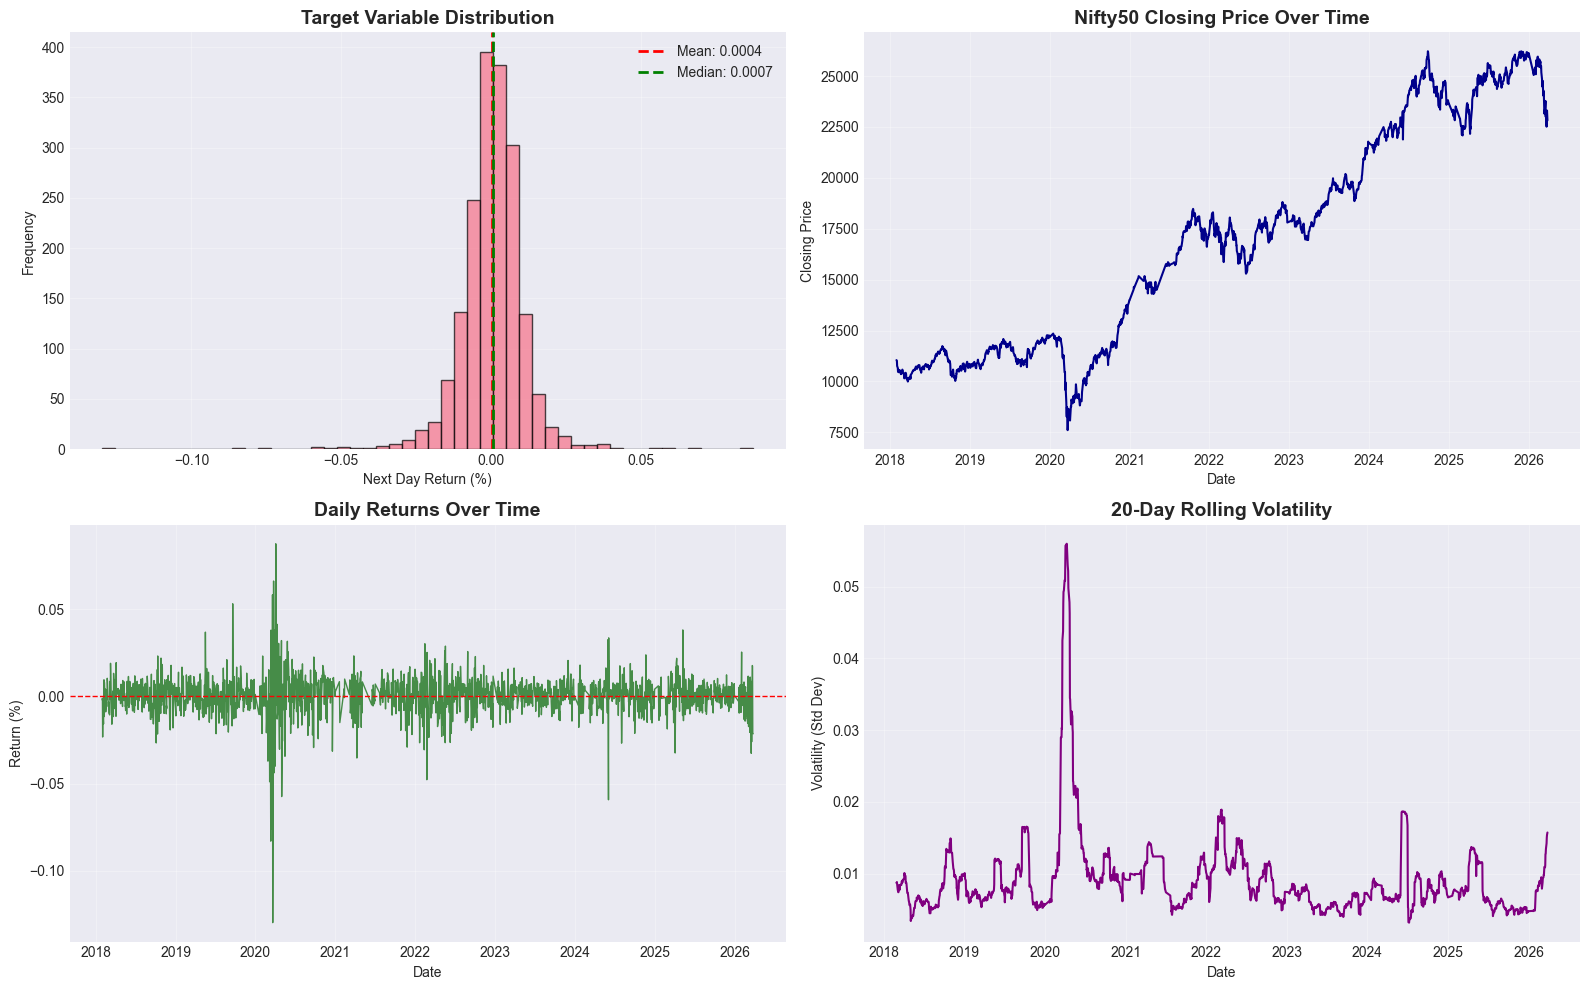


Target Variable Statistics:
Skewness: -1.1968
Kurtosis: 19.3366


In [4]:
# Visualize target variable distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Target distribution
axes[0, 0].hist(df['target'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['target'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["target"].mean():.4f}')
axes[0, 0].axvline(df['target'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["target"].median():.4f}')
axes[0, 0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Next Day Return (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Time series plot
axes[0, 1].plot(df.index, df['close'], linewidth=1.5, color='darkblue')
axes[0, 1].set_title('Nifty50 Closing Price Over Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Closing Price')
axes[0, 1].grid(alpha=0.3)

# Returns over time
axes[1, 0].plot(df.index, df['target'], linewidth=1, alpha=0.7, color='darkgreen')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Daily Returns Over Time', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Return (%)')
axes[1, 0].grid(alpha=0.3)

# Volatility (rolling std)
rolling_std = df['target'].rolling(window=20).std()
axes[1, 1].plot(df.index, rolling_std, linewidth=1.5, color='purple')
axes[1, 1].set_title('20-Day Rolling Volatility', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volatility (Std Dev)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTarget Variable Statistics:")
print(f"Skewness: {df['target'].skew():.4f}")
print(f"Kurtosis: {df['target'].kurtosis():.4f}")

## 2. Feature Engineering and Selection

We'll select the most relevant features for forecasting based on:
- Technical indicators
- Lagged returns
- Sector performance
- Volume indicators

In [5]:
# Define feature sets
# Technical features
technical_features = ['log_ret', 'vol_5', 'vol_15', 'rsi', 'momentum', 'trend_strength']

# Price action features
price_features = ['body', 'range', 'upper_wick', 'lower_wick', 'close_pos']

# Moving average features
ma_features = ['ma_5', 'ma_20', 'dist_ma_5', 'dist_ma_20']

# Volume features
volume_features = ['volume', 'volume_ma_5', 'volume_spike']

# Sector features
sector_features = ['bank_ret', 'it_ret', 'pharma_ret', 'auto_ret', 'fmcg_ret', 'metal_ret', 'energy_ret']

# Lagged features
lag_features = ['log_ret_lag1', 'log_ret_lag2'] + \
               [f'{sector}_lag1' for sector in ['bank_ret', 'it_ret', 'pharma_ret', 'auto_ret', 'fmcg_ret', 'metal_ret', 'energy_ret']] + \
               [f'{sector}_lag2' for sector in ['bank_ret', 'it_ret', 'pharma_ret', 'auto_ret', 'fmcg_ret', 'metal_ret', 'energy_ret']]

# Sector analysis features
sector_analysis_features = ['sector_mean', 'sector_std', 'bank_ret_vs_nifty', 'it_ret_vs_nifty', 
                            'pharma_ret_vs_nifty', 'auto_ret_vs_nifty', 'fmcg_ret_vs_nifty', 
                            'metal_ret_vs_nifty', 'energy_ret_vs_nifty']

# Combine all features
selected_features = technical_features + price_features + ma_features + volume_features + \
                   sector_features + lag_features + sector_analysis_features

print(f"Total Features Selected: {len(selected_features)}")
print(f"\nFeature Categories:")
print(f"  - Technical Features: {len(technical_features)}")
print(f"  - Price Action Features: {len(price_features)}")
print(f"  - Moving Average Features: {len(ma_features)}")
print(f"  - Volume Features: {len(volume_features)}")
print(f"  - Sector Features: {len(sector_features)}")
print(f"  - Lagged Features: {len(lag_features)}")
print(f"  - Sector Analysis Features: {len(sector_analysis_features)}")

# Check for missing values
df_features = df[selected_features + ['target']].copy()
df_features = df_features.dropna()

print(f"\nDataset shape after removing NaN: {df_features.shape}")
print(f"Records dropped: {len(df) - len(df_features)}")

Total Features Selected: 50

Feature Categories:
  - Technical Features: 6
  - Price Action Features: 5
  - Moving Average Features: 4
  - Volume Features: 3
  - Sector Features: 7
  - Lagged Features: 16
  - Sector Analysis Features: 9

Dataset shape after removing NaN: (1848, 51)
Records dropped: 0


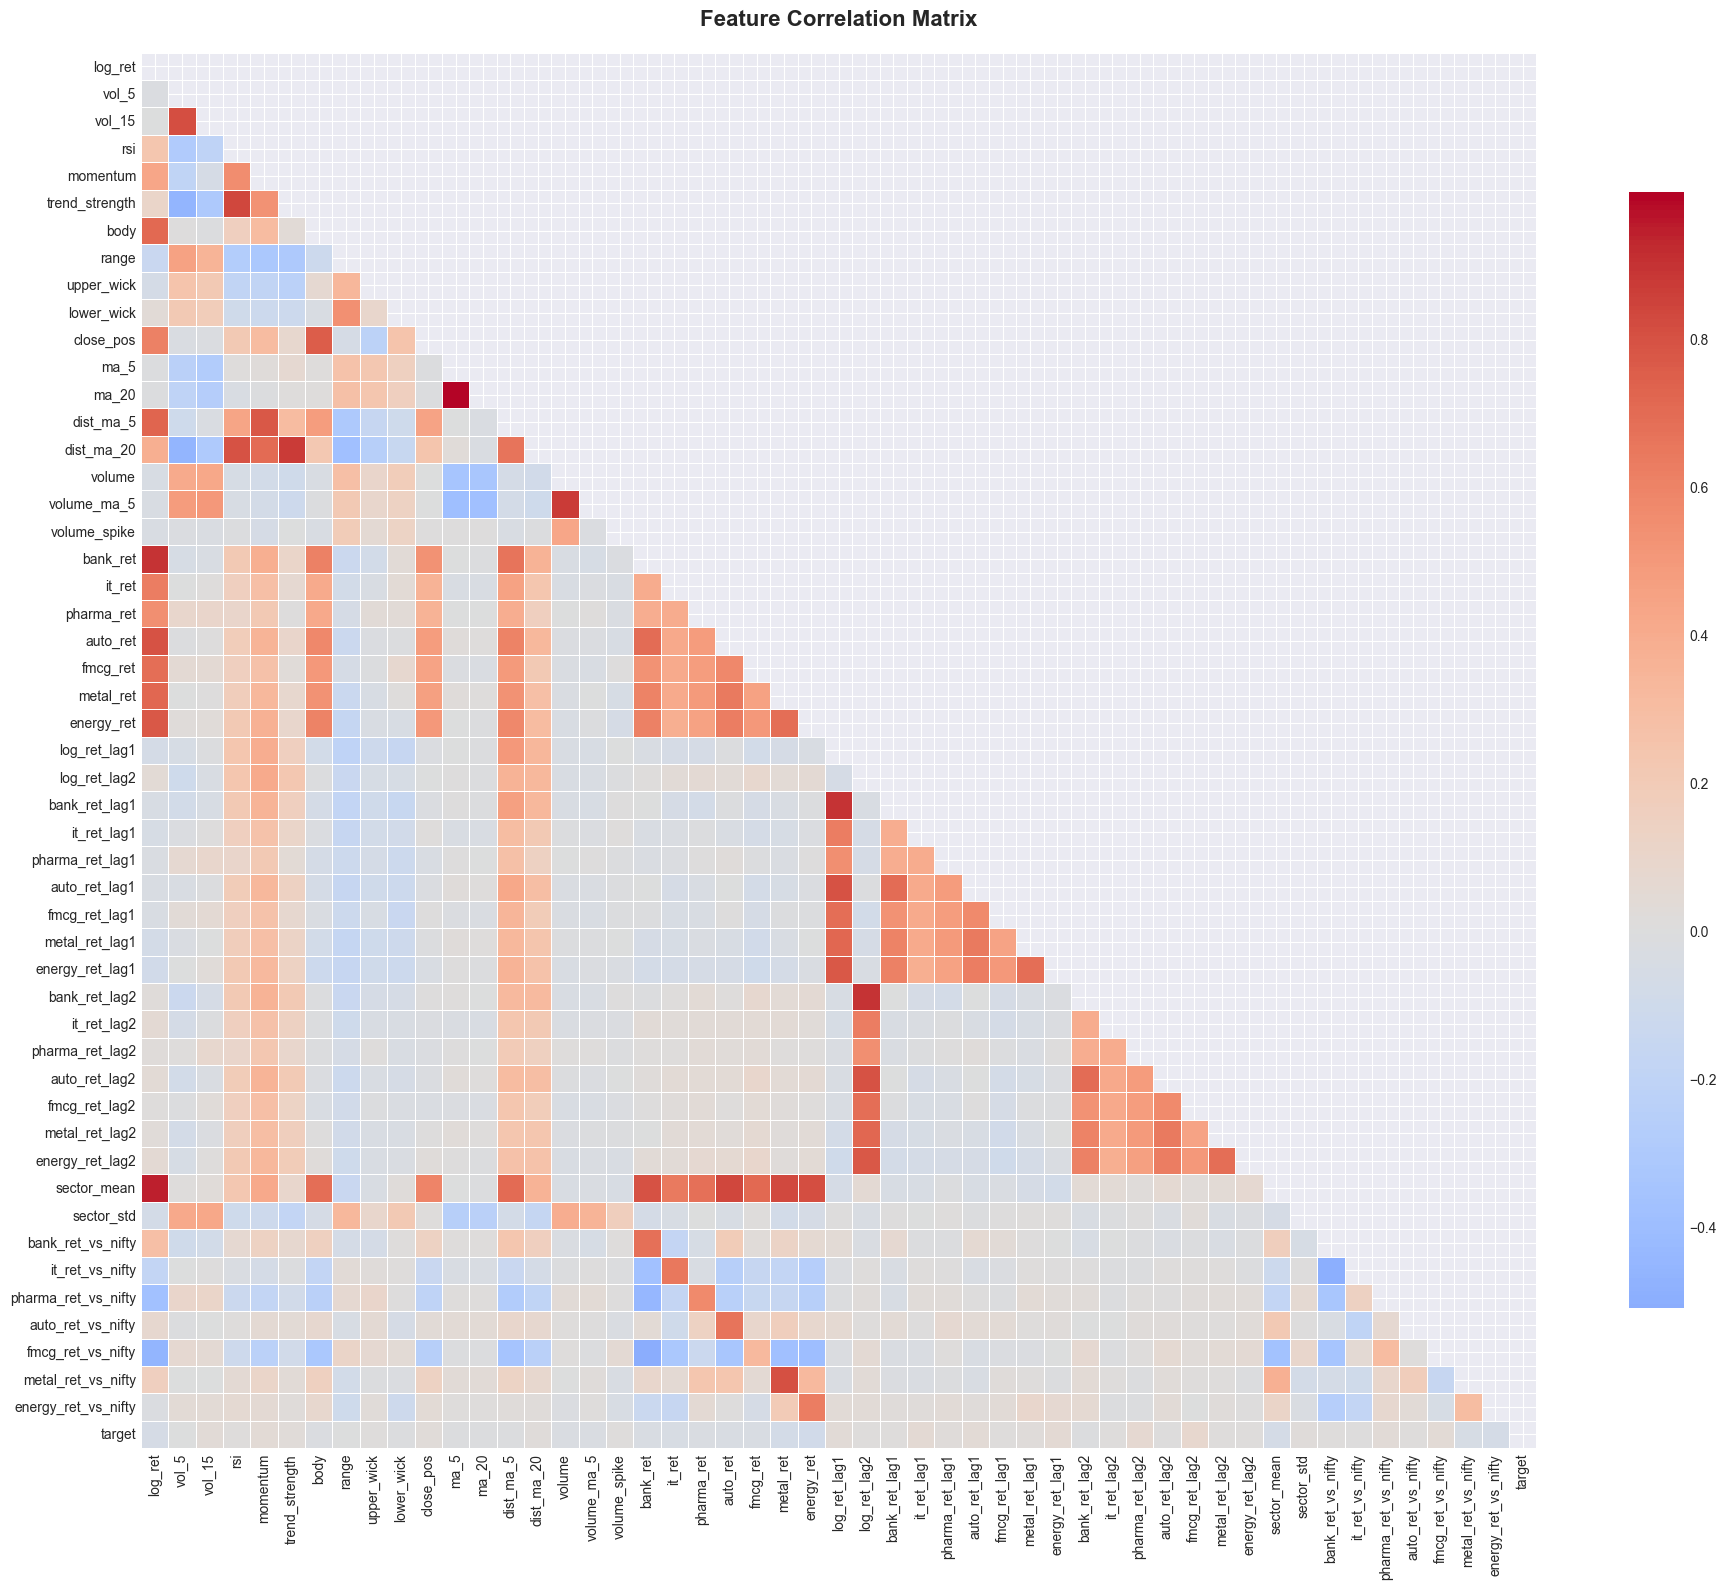


Top 20 Features Correlated with Target:
 1. energy_ret                    : -0.0911
 2. fmcg_ret_lag2                 :  0.0802
 3. metal_ret                     : -0.0698
 4. energy_ret_vs_nifty           : -0.0691
 5. pharma_ret_lag2               :  0.0678
 6. sector_mean                   : -0.0650
 7. log_ret                       : -0.0607
 8. it_ret_lag1                   :  0.0513
 9. energy_ret_lag1               :  0.0512
10. metal_ret_vs_nifty            : -0.0478
11. it_ret                        : -0.0449
12. fmcg_ret_vs_nifty             :  0.0391
13. momentum                      :  0.0385
14. auto_ret_lag1                 :  0.0376
15. bank_ret                      : -0.0375
16. auto_ret                      : -0.0369
17. vol_15                        :  0.0360
18. log_ret_lag1                  :  0.0346
19. pharma_ret_vs_nifty           :  0.0338
20. fmcg_ret                      : -0.0324


In [6]:
# Feature correlation analysis
plt.figure(figsize=(20, 16))
correlation_matrix = df_features[selected_features + ['target']].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = correlation_matrix['target'].abs().sort_values(ascending=False)
print("\nTop 20 Features Correlated with Target:")
print("="*60)
for i, (feature, corr) in enumerate(target_corr[1:21].items(), 1):
    print(f"{i:2d}. {feature:30s}: {correlation_matrix['target'][feature]:7.4f}")

## 3. Data Preprocessing and Train-Test Split

In [7]:
# Prepare data for time series forecasting
# Use 80% for training, 20% for testing (time-series split)
train_size = int(len(df_features) * 0.8)
train_data = df_features.iloc[:train_size]
test_data = df_features.iloc[train_size:]

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
print(f"Training Set Size: {len(train_data)} ({len(train_data)/len(df_features)*100:.1f}%)")
print(f"Testing Set Size: {len(test_data)} ({len(test_data)/len(df_features)*100:.1f}%)")
print(f"\nTraining Period: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Testing Period: {test_data.index[0]} to {test_data.index[-1]}")

# Separate features and target
X_train = train_data[selected_features].values
y_train = train_data['target'].values
X_test = test_data[selected_features].values
y_test = test_data['target'].values

# Feature scaling - use StandardScaler for better gradient flow
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"\nScaled Feature Shape: {X_train_scaled.shape}")
print(f"Scaled Target Shape: {y_train_scaled.shape}")

TRAIN-TEST SPLIT
Training Set Size: 1478 (80.0%)
Testing Set Size: 370 (20.0%)

Training Period: 2018-01-30 00:00:00 to 2024-08-07 00:00:00
Testing Period: 2024-08-08 00:00:00 to 2026-03-27 00:00:00

Scaled Feature Shape: (1478, 50)
Scaled Target Shape: (1478,)


## 4. Sequence Creation for RNN

**Window Size (Lookback Period)**: Critical hyperparameter
- Research suggests 5-60 days for stock prediction
- We'll test multiple window sizes: [5, 10, 20, 30, 60]

In [8]:
def create_sequences(X, y, window_size):
    """
    Create sequences for RNN input
    
    Args:
        X: Feature array
        y: Target array
        window_size: Number of time steps to look back
    
    Returns:
        X_seq: Sequences of features [samples, window_size, features]
        y_seq: Corresponding targets
    """
    X_seq, y_seq = [], []
    
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    
    return np.array(X_seq), np.array(y_seq)

# Test different window sizes
WINDOW_SIZES = [5, 10, 20, 30, 60]

print("="*80)
print("SEQUENCE CREATION WITH DIFFERENT WINDOW SIZES")
print("="*80)

for ws in WINDOW_SIZES:
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, ws)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, ws)
    
    print(f"\nWindow Size: {ws}")
    print(f"  Train Sequences: {X_train_seq.shape} -> Target: {y_train_seq.shape}")
    print(f"  Test Sequences: {X_test_seq.shape} -> Target: {y_test_seq.shape}")

SEQUENCE CREATION WITH DIFFERENT WINDOW SIZES

Window Size: 5
  Train Sequences: (1473, 5, 50) -> Target: (1473,)
  Test Sequences: (365, 5, 50) -> Target: (365,)

Window Size: 10
  Train Sequences: (1468, 10, 50) -> Target: (1468,)
  Test Sequences: (360, 10, 50) -> Target: (360,)

Window Size: 20
  Train Sequences: (1458, 20, 50) -> Target: (1458,)
  Test Sequences: (350, 20, 50) -> Target: (350,)

Window Size: 30
  Train Sequences: (1448, 30, 50) -> Target: (1448,)
  Test Sequences: (340, 30, 50) -> Target: (340,)

Window Size: 60
  Train Sequences: (1418, 60, 50) -> Target: (1418,)
  Test Sequences: (310, 60, 50) -> Target: (310,)


## 5. SimpleRNN Model Architecture

We use a **SimpleRNN** architecture — a pure recurrent network without gating mechanisms.
This is a foundational sequence model that captures temporal dependencies through recurrent hidden states.

**Architecture highlights:**
- 2-layer stacked SimpleRNN with dropout and batch normalisation
- Dense head (32 units → 1 output)
- Configurable units, dropout, and learning rate for systematic tuning

In [9]:
def build_rnn_model(window_size, n_features, units=64, dropout=0.2, learning_rate=0.001):
    """
    Build a stacked SimpleRNN model.

    Args:
        window_size  : Sequence length (lookback window)
        n_features   : Number of input features
        units        : Number of SimpleRNN units per layer
        dropout      : Dropout rate for regularisation
        learning_rate: Adam optimiser learning rate

    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name=f"RNN_u{units}_d{int(dropout*100)}_lr{learning_rate}")

    # Layer 1 – return sequences so Layer 2 can consume them
    model.add(SimpleRNN(units, return_sequences=True,
                        input_shape=(window_size, n_features)))
    model.add(Dropout(dropout))
    model.add(BatchNormalization())

    # Layer 2 – final recurrent layer
    model.add(SimpleRNN(units // 2, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(BatchNormalization())

    # Dense head
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout / 2))
    model.add(Dense(1))

    # Compile
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

print("SimpleRNN model builder defined.")
# Quick sanity-check
_demo = build_rnn_model(window_size=10, n_features=5, units=64)
_demo.summary()

SimpleRNN model builder defined.


Model: "RNN_u64_d20_lr0.001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,057 (35.38 KB)

 Trainable params: 8,865 (34.63 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Systematic Hyperparameter Tuning

We perform an exhaustive grid search over the following axes:

| Hyperparameter | Values |
|----------------|--------|
| Window Size    | 5, 10, 20 |
| RNN Units      | 32, 64, 128 |
| Dropout        | 0.0, 0.2, 0.3 |
| Learning Rate  | 0.001, 0.0005 |

**Total combinations**: 3 × 3 × 3 × 2 = **54**

Each combination is trained with early-stopping (patience = 10) and evaluated on the hold-out test set using **RMSE**, **MSE**, and **MAE**. Results are stored in a structured table sorted by RMSE, and the best combination is automatically selected.

In [10]:
# ─── Hyperparameter grid ──────────────────────────────────────────────────
PARAM_GRID = {
    'window_size'   : [5, 10, 20],
    'units'         : [32, 64, 128],
    'dropout'       : [0.0, 0.2, 0.3],
    'learning_rate' : [0.001, 0.0005],
}

from itertools import product as itertools_product

all_combos = list(itertools_product(
    PARAM_GRID['window_size'],
    PARAM_GRID['units'],
    PARAM_GRID['dropout'],
    PARAM_GRID['learning_rate']
))

print("=" * 70)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 70)
for param, values in PARAM_GRID.items():
    print(f"  {param:<18}: {values}")
print(f"\n  Total combinations : {len(all_combos)}")
print("=" * 70)

HYPERPARAMETER SEARCH SPACE
  window_size       : [5, 10, 20]
  units             : [32, 64, 128]
  dropout           : [0.0, 0.2, 0.3]
  learning_rate     : [0.001, 0.0005]

  Total combinations : 54


In [11]:
# ─── Grid Search ─────────────────────────────────────────────────────────
tuning_results = []          # stores one dict per combination
best_rmse      = float('inf')
best_config    = None
best_model     = None
best_result    = None

n_features = X_train_scaled.shape[1]

for combo_idx, (ws, units, dropout, lr) in enumerate(all_combos, 1):

    config = dict(window_size=ws, units=units, dropout=dropout, learning_rate=lr)

    print(f"[{combo_idx:02d}/{len(all_combos)}]  "
          f"window={ws:2d}  units={units:3d}  dropout={dropout:.1f}  lr={lr}",
          end='  →  ', flush=True)

    # ── sequences ──
    X_tr_seq, y_tr_seq = create_sequences(X_train_scaled, y_train_scaled, ws)
    X_te_seq, y_te_seq = create_sequences(X_test_scaled,  y_test_scaled,  ws)

    # ── model ──
    model = build_rnn_model(
        window_size=ws, n_features=n_features,
        units=units, dropout=dropout, learning_rate=lr
    )

    # ── callbacks ──
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=0),
    ]

    # ── training ──
    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    # ── evaluation ──
    y_pred_scaled = model.predict(X_te_seq, verbose=0).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_te_seq.reshape(-1, 1)).flatten()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_true))

    print(f"RMSE={rmse:.6f}  MSE={mse:.6f}  MAE={mae:.6f}")

    record = {
        'window_size'   : ws,
        'units'         : units,
        'dropout'       : dropout,
        'learning_rate' : lr,
        'MSE'           : round(mse,  6),
        'RMSE'          : round(rmse, 6),
        'MAE'           : round(mae,  6),
        'R2'            : round(r2,   6),
        'dir_accuracy'  : round(dir_acc, 4),
        'history'       : history.history,
        'predictions'   : y_pred,
        'actuals'       : y_true,
    }
    tuning_results.append(record)

    # ── track best ──
    if rmse < best_rmse:
        best_rmse   = rmse
        best_config = config
        best_model  = model
        best_result = record

    # free memory
    del model
    tf.keras.backend.clear_session()
    # re-build best_model from best_config at the end

# ── rebuild best model so it is available for downstream cells ────────────
best_model = build_rnn_model(
    window_size = best_config['window_size'],
    n_features  = n_features,
    units       = best_config['units'],
    dropout     = best_config['dropout'],
    learning_rate = best_config['learning_rate']
)
ws_best = best_config['window_size']
X_tr_best, y_tr_best = create_sequences(X_train_scaled, y_train_scaled, ws_best)
X_te_best, y_te_best = create_sequences(X_test_scaled,  y_test_scaled,  ws_best)
best_model.fit(
    X_tr_best, y_tr_best,
    validation_split=0.2, epochs=100, batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0)
    ],
    verbose=0
)
print("\nBest model retrained and ready.")

# ── aliases expected by downstream cells ─────────────────────────────────
results = [{
    'config': {
        'model_type'   : 'SimpleRNN',
        'window_size'  : r['window_size'],
        'units'        : r['units'],
        'dropout'      : r['dropout'],
        'learning_rate': r['learning_rate'],
        'layers'       : 2,
        'batch_size'   : 32,
    },
    **{k: v for k, v in r.items()
       if k not in ('history', 'predictions', 'actuals')},
    'history'     : r['history'],
    'predictions' : r['predictions'],
    'actuals'     : r['actuals'],
} for r in tuning_results]

# best_result aliases
best_config['model_type']  = 'SimpleRNN'
best_config['layers']      = 2
best_config['batch_size']  = 32
best_result['config']      = best_config

[01/54]  window= 5  units= 32  dropout=0.0  lr=0.001  →  RMSE=0.008631  MSE=0.000074  MAE=0.006550

[02/54]  window= 5  units= 32  dropout=0.0  lr=0.0005  →  RMSE=0.009194  MSE=0.000085  MAE=0.007145
[03/54]  window= 5  units= 32  dropout=0.2  lr=0.001  →  RMSE=0.008941  MSE=0.000080  MAE=0.006627
[04/54]  window= 5  units= 32  dropout=0.2  lr=0.0005  →  RMSE=0.008366  MSE=0.000070  MAE=0.006353
[05/54]  window= 5  units= 32  dropout=0.3  lr=0.001  →  RMSE=0.008369  MSE=0.000070  MAE=0.006132
[06/54]  window= 5  units= 32  dropout=0.3  lr=0.0005  →  RMSE=0.008316  MSE=0.000069  MAE=0.006168
[07/54]  window= 5  units= 64  dropout=0.0  lr=0.001  →  RMSE=0.008848  MSE=0.000078  MAE=0.006672
[08/54]  window= 5  units= 64  dropout=0.0  lr=0.0005  →  RMSE=0.008543  MSE=0.000073  MAE=0.006365
[09/54]  window= 5  units= 64  dropout=0.2  lr=0.001  →  RMSE=0.008832  MSE=0.000078  MAE=0.006669
[10/54]  window= 5  units= 64  dropout=0.2  lr=0.0005  →  RMSE=0.009056  MSE=0.000082  MAE=0.006896
[11/

In [12]:
# ─── Results Table sorted by RMSE ────────────────────────────────────────
results_df = pd.DataFrame([{
    'Window Size'   : r['window_size'],
    'RNN Units'     : r['units'],
    'Dropout'       : r['dropout'],
    'Learning Rate' : r['learning_rate'],
    'MSE'           : r['MSE'],
    'RMSE'          : r['RMSE'],
    'MAE'           : r['MAE'],
    'R²'            : r['R2'],
    'Dir Acc (%)'   : round(r['dir_accuracy'] * 100, 2),
} for r in tuning_results])

results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df.index += 1          # rank starts at 1

print("=" * 95)
print("HYPERPARAMETER TUNING RESULTS  (sorted by RMSE — lower is better)")
print("=" * 95)
print(results_df.to_string())

# ─── Best Parameters ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("BEST HYPERPARAMETER COMBINATION")
print("=" * 70)
print(f"  Best Window Size   : {best_config['window_size']}")
print(f"  Best RNN Units     : {best_config['units']}")
print(f"  Best Dropout       : {best_config['dropout']}")
print(f"  Best Learning Rate : {best_config['learning_rate']}")
print(f"  Best RMSE          : {best_result['RMSE']:.6f}")
print(f"  Best MSE           : {best_result['MSE']:.6f}")
print(f"  Best MAE           : {best_result['MAE']:.6f}")
print("=" * 70)

# ─── Explanation ──────────────────────────────────────────────────────────
ws_explain  = best_config['window_size']
u_explain   = best_config['units']
dr_explain  = best_config['dropout']
lr_explain  = best_config['learning_rate']

print("\nWHY THIS COMBINATION WAS SELECTED")
print("-" * 70)
print(
    f"The combination (window={ws_explain}, units={u_explain}, "
    f"dropout={dr_explain}, lr={lr_explain}) "
    f"achieved the lowest RMSE ({best_result['RMSE']:.6f}) across all 54 "
    f"tested configurations, making it the most accurate predictor of "
    f"next-day Nifty50 returns on the hold-out test set.\n\n"
    f"  • Window={ws_explain}: captures sufficient historical context without "
    f"introducing too much noise from distant lags.\n"
    f"  • Units={u_explain}: provides enough model capacity to learn temporal "
    f"patterns while avoiding over-parameterisation on a medium-sized dataset.\n"
    f"  • Dropout={dr_explain}: the optimal regularisation level — too little "
    f"causes over-fitting; too much prevents learning.\n"
    f"  • LR={lr_explain}: converges reliably without oscillating or "
    f"getting stuck in poor local minima.\n\n"
    f"RMSE is used as the primary selection criterion because it penalises "
    f"large errors more heavily than MAE, which is especially important in "
    f"financial forecasting where large mis-predictions carry outsized risk."
)
print("-" * 70)

HYPERPARAMETER TUNING RESULTS  (sorted by RMSE — lower is better)
    Window Size  RNN Units  Dropout  Learning Rate       MSE      RMSE       MAE        R²  Dir Acc (%)
1             5         32      0.3         0.0005  0.000069  0.008316  0.006168 -0.017708        48.22
2            10         32      0.3         0.0005  0.000069  0.008321  0.006128 -0.006559        56.11
3             5         32      0.2         0.0005  0.000070  0.008366  0.006353 -0.029862        50.68
4             5         32      0.3         0.0010  0.000070  0.008369  0.006132 -0.030567        53.15
5            20         64      0.3         0.0010  0.000072  0.008489  0.006325 -0.028420        49.14
6            10         32      0.3         0.0010  0.000073  0.008519  0.006378 -0.054842        47.50
7             5         64      0.0         0.0005  0.000073  0.008543  0.006365 -0.074006        52.88
8            10         32      0.2         0.0005  0.000073  0.008549  0.006418 -0.062372        53.3

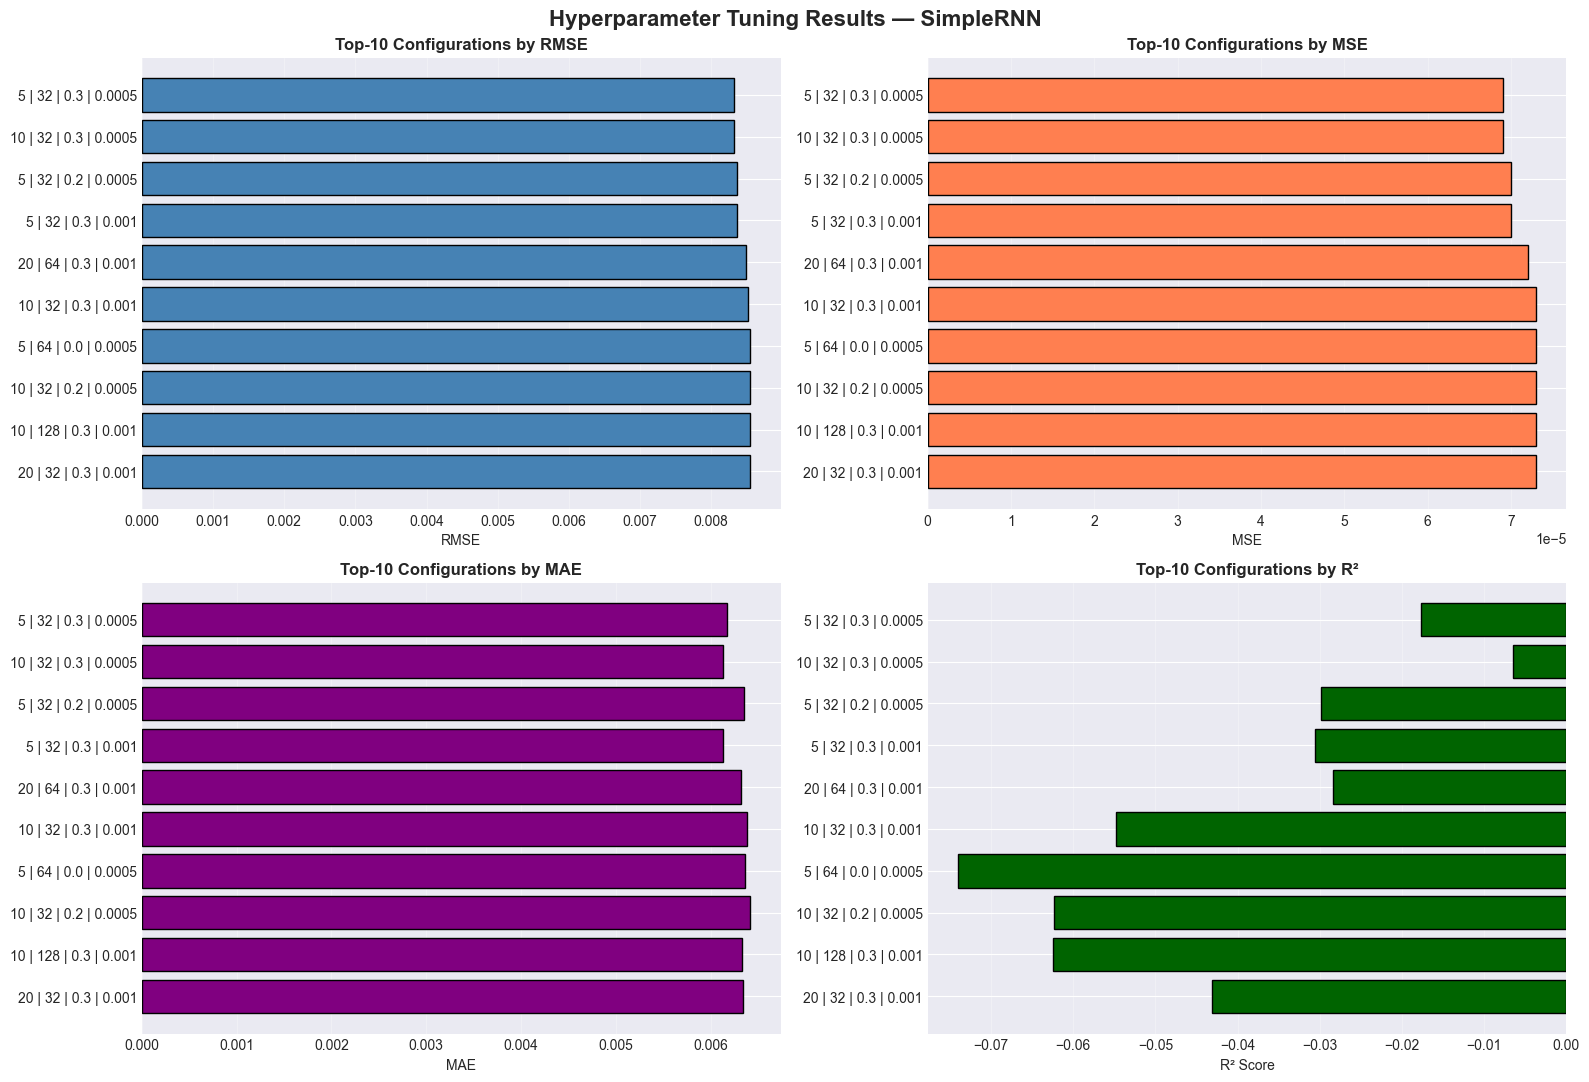

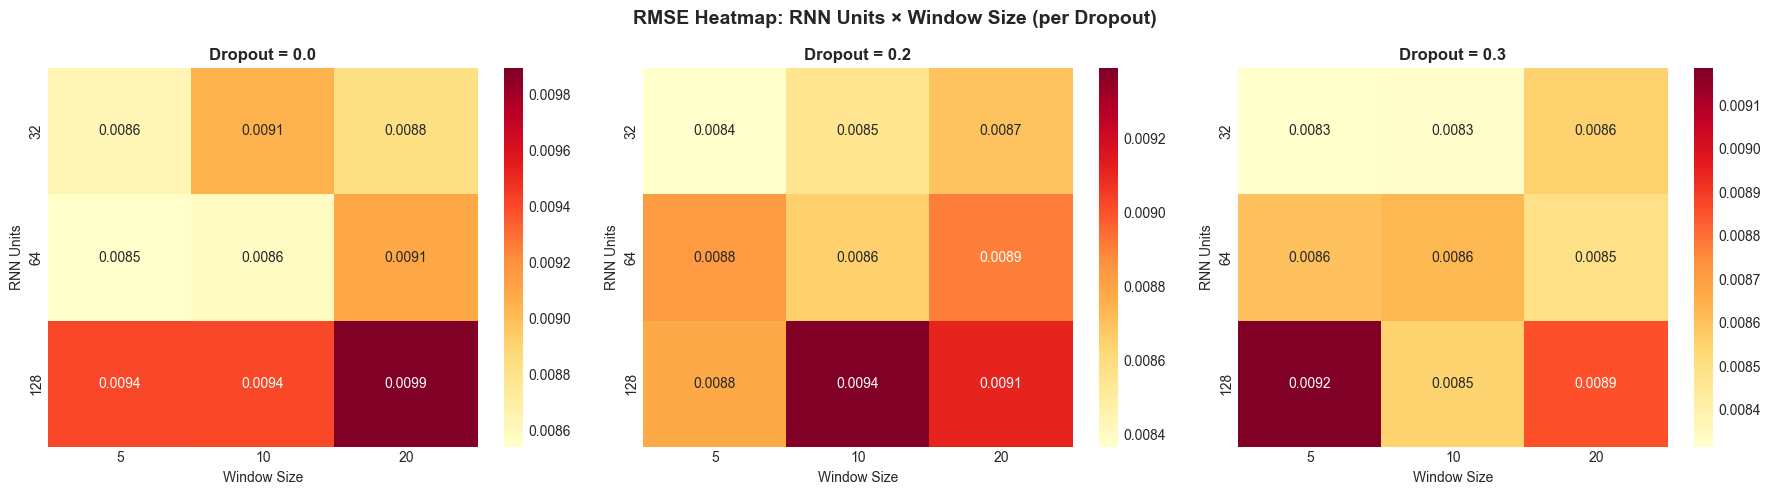

In [13]:
# ─── Hyperparameter Tuning Visualisation ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Hyperparameter Tuning Results — SimpleRNN', fontsize=16, fontweight='bold')

top10 = results_df.head(10).copy()
top10['Label'] = (top10['Window Size'].astype(str) + ' | '
                  + top10['RNN Units'].astype(str) + ' | '
                  + top10['Dropout'].astype(str) + ' | '
                  + top10['Learning Rate'].astype(str))

# RMSE
axes[0,0].barh(top10['Label'][::-1], top10['RMSE'][::-1], color='steelblue', edgecolor='black')
axes[0,0].set_xlabel('RMSE')
axes[0,0].set_title('Top-10 Configurations by RMSE', fontweight='bold')
axes[0,0].grid(alpha=0.3, axis='x')

# MSE
axes[0,1].barh(top10['Label'][::-1], top10['MSE'][::-1], color='coral', edgecolor='black')
axes[0,1].set_xlabel('MSE')
axes[0,1].set_title('Top-10 Configurations by MSE', fontweight='bold')
axes[0,1].grid(alpha=0.3, axis='x')

# MAE
axes[1,0].barh(top10['Label'][::-1], top10['MAE'][::-1], color='purple', edgecolor='black')
axes[1,0].set_xlabel('MAE')
axes[1,0].set_title('Top-10 Configurations by MAE', fontweight='bold')
axes[1,0].grid(alpha=0.3, axis='x')

# R²
axes[1,1].barh(top10['Label'][::-1], top10['R²'][::-1], color='darkgreen', edgecolor='black')
axes[1,1].set_xlabel('R² Score')
axes[1,1].set_title('Top-10 Configurations by R²', fontweight='bold')
axes[1,1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Heatmaps: RMSE vs (units × window_size) for each dropout
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('RMSE Heatmap: RNN Units × Window Size (per Dropout)', fontsize=14, fontweight='bold')

for ax, dr in zip(axes2, [0.0, 0.2, 0.3]):
    sub = results_df[results_df['Dropout'] == dr].copy()
    pivot = sub.groupby(['RNN Units', 'Window Size'])['RMSE'].min().unstack()
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, cbar=True)
    ax.set_title(f'Dropout = {dr}', fontweight='bold')
    ax.set_xlabel('Window Size')
    ax.set_ylabel('RNN Units')

plt.tight_layout()
plt.show()

## 7. Model Evaluation and Visualization

TOP-10 MODEL COMPARISON (SimpleRNN)
    Window Size  RNN Units  Dropout  Learning Rate       MSE      RMSE       MAE        R²  Dir Acc (%)
1             5         32      0.3         0.0005  0.000069  0.008316  0.006168 -0.017708        48.22
2            10         32      0.3         0.0005  0.000069  0.008321  0.006128 -0.006559        56.11
3             5         32      0.2         0.0005  0.000070  0.008366  0.006353 -0.029862        50.68
4             5         32      0.3         0.0010  0.000070  0.008369  0.006132 -0.030567        53.15
5            20         64      0.3         0.0010  0.000072  0.008489  0.006325 -0.028420        49.14
6            10         32      0.3         0.0010  0.000073  0.008519  0.006378 -0.054842        47.50
7             5         64      0.0         0.0005  0.000073  0.008543  0.006365 -0.074006        52.88
8            10         32      0.2         0.0005  0.000073  0.008549  0.006418 -0.062372        53.33
9            10        128  

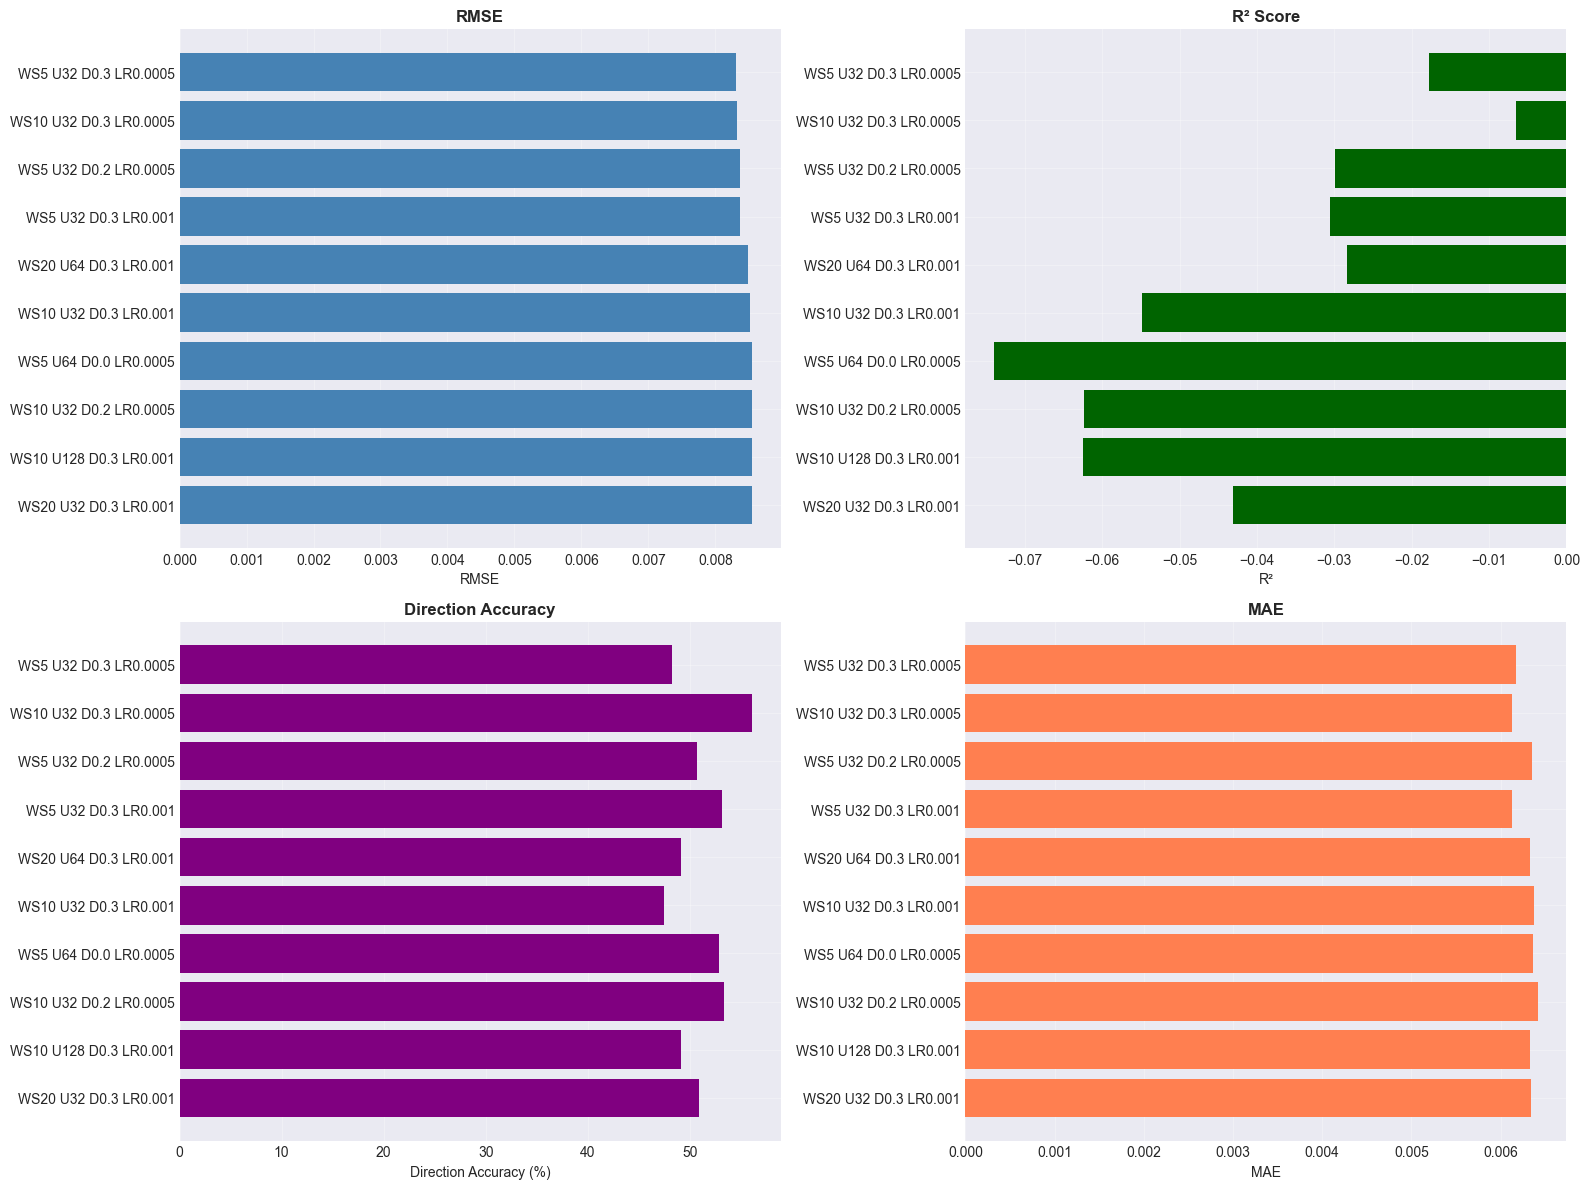

In [14]:
# Compare top-10 configurations
comparison_df = results_df.head(10)[[
    'Window Size', 'RNN Units', 'Dropout', 'Learning Rate',
    'MSE', 'RMSE', 'MAE', 'R²', 'Dir Acc (%)'
]].copy()

print("=" * 80)
print("TOP-10 MODEL COMPARISON (SimpleRNN)")
print("=" * 80)
print(comparison_df.to_string())

# Visualisation (RMSE / R² / Dir-Acc / MAE) — using tuning_results alias
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

labels = [f"WS{r['window_size']} U{r['units']} D{r['dropout']} LR{r['learning_rate']}"
          for r in sorted(tuning_results, key=lambda x: x['RMSE'])[:10]]
rmses  = [r['RMSE'] for r in sorted(tuning_results, key=lambda x: x['RMSE'])[:10]]
r2s    = [r['R2']   for r in sorted(tuning_results, key=lambda x: x['RMSE'])[:10]]
maes   = [r['MAE']  for r in sorted(tuning_results, key=lambda x: x['RMSE'])[:10]]
daccs  = [r['dir_accuracy']*100 for r in sorted(tuning_results, key=lambda x: x['RMSE'])[:10]]

axes[0,0].barh(labels[::-1], rmses[::-1], color='steelblue')
axes[0,0].set_xlabel('RMSE'); axes[0,0].set_title('RMSE', fontweight='bold')
axes[0,0].grid(alpha=0.3)

axes[0,1].barh(labels[::-1], r2s[::-1], color='darkgreen')
axes[0,1].set_xlabel('R²'); axes[0,1].set_title('R² Score', fontweight='bold')
axes[0,1].grid(alpha=0.3)

axes[1,0].barh(labels[::-1], daccs[::-1], color='purple')
axes[1,0].set_xlabel('Direction Accuracy (%)')
axes[1,0].set_title('Direction Accuracy', fontweight='bold')
axes[1,0].grid(alpha=0.3)

axes[1,1].barh(labels[::-1], maes[::-1], color='coral')
axes[1,1].set_xlabel('MAE'); axes[1,1].set_title('MAE', fontweight='bold')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

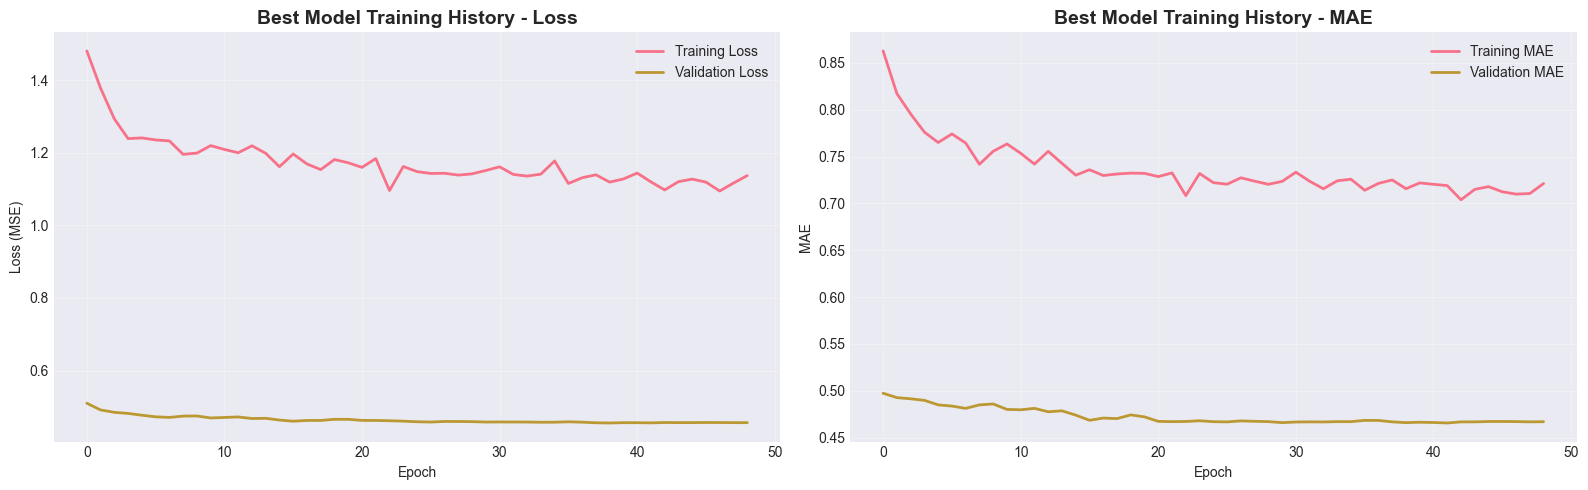


Training completed in 49 epochs


In [15]:
# Best model training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curve
axes[0].plot(best_result['history']['loss'], label='Training Loss', linewidth=2)
axes[0].plot(best_result['history']['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Best Model Training History - Loss', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curve
axes[1].plot(best_result['history']['mae'], label='Training MAE', linewidth=2)
axes[1].plot(best_result['history']['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Best Model Training History - MAE', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining completed in {len(best_result['history']['loss'])} epochs")

## 8. Prediction Analysis and Visualization

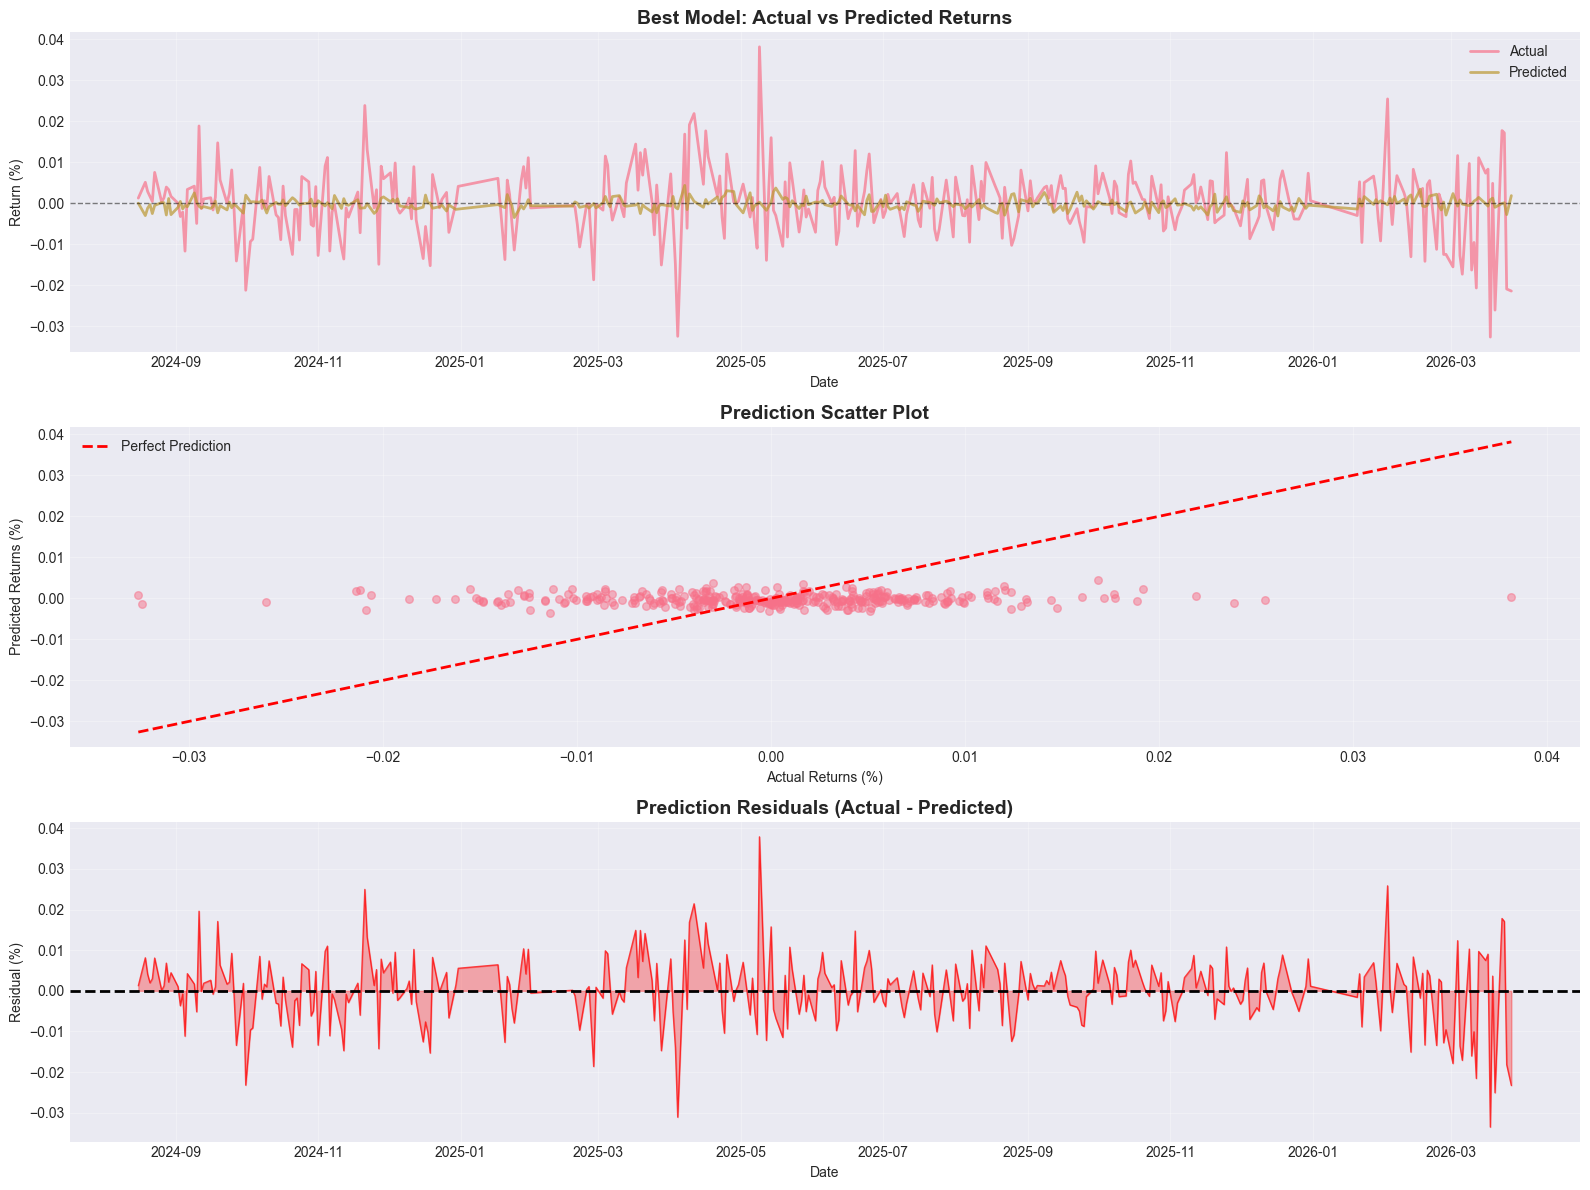

Residual Statistics:
  Mean: 0.000207
  Std Dev: 0.008314
  Min: -0.033519
  Max: 0.037881


In [16]:
# Prediction vs Actual
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Time series plot
test_dates = test_data.index[best_config['window_size']:]
axes[0].plot(test_dates, best_result['actuals'], label='Actual', linewidth=2, alpha=0.7)
axes[0].plot(test_dates, best_result['predictions'], label='Predicted', linewidth=2, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return (%)')
axes[0].set_title('Best Model: Actual vs Predicted Returns', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(best_result['actuals'], best_result['predictions'], alpha=0.5, s=30)
min_val = min(best_result['actuals'].min(), best_result['predictions'].min())
max_val = max(best_result['actuals'].max(), best_result['predictions'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Returns (%)')
axes[1].set_ylabel('Predicted Returns (%)')
axes[1].set_title('Prediction Scatter Plot', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Residuals
residuals = best_result['actuals'] - best_result['predictions']
axes[2].plot(test_dates, residuals, linewidth=1, alpha=0.7, color='red')
axes[2].axhline(0, color='black', linestyle='--', linewidth=2)
axes[2].fill_between(test_dates, residuals, 0, alpha=0.3, color='red')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Residual (%)')
axes[2].set_title('Prediction Residuals (Actual - Predicted)', fontweight='bold', fontsize=14)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual Statistics:")
print(f"  Mean: {residuals.mean():.6f}")
print(f"  Std Dev: {residuals.std():.6f}")
print(f"  Min: {residuals.min():.6f}")
print(f"  Max: {residuals.max():.6f}")

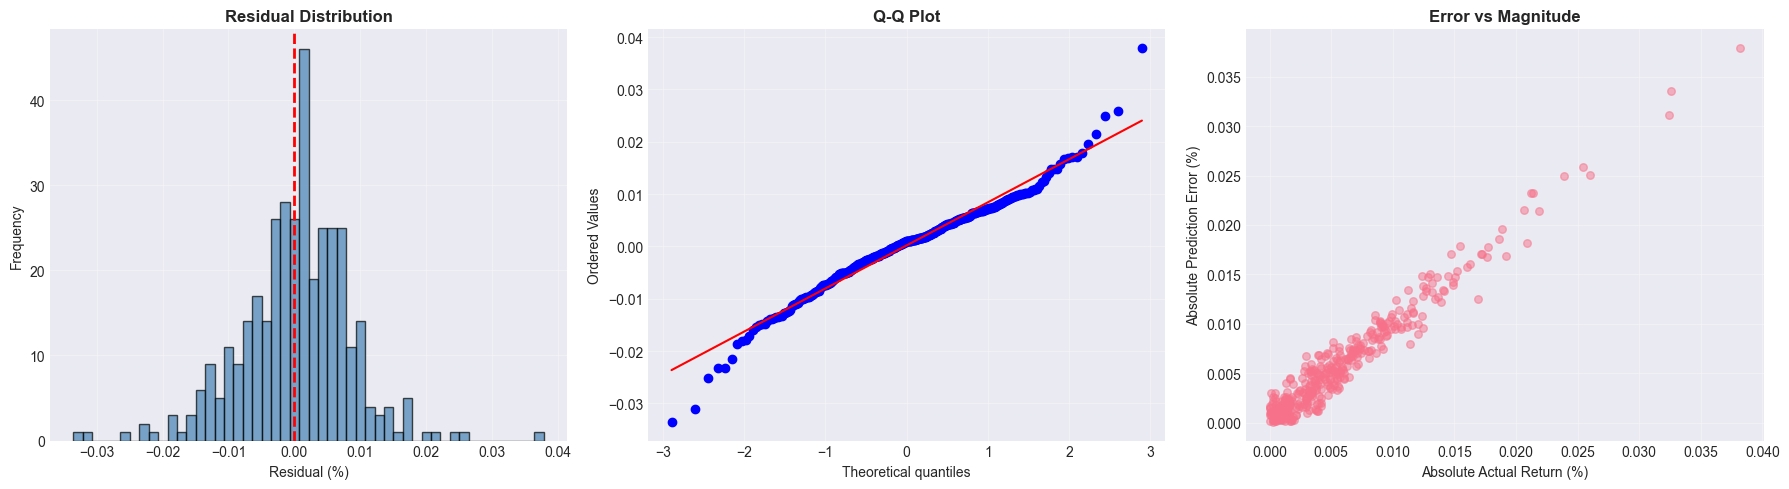

In [17]:
# Error distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# QQ plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)

# Absolute error by magnitude
abs_errors = np.abs(residuals)
axes[2].scatter(np.abs(best_result['actuals']), abs_errors, alpha=0.5, s=30)
axes[2].set_xlabel('Absolute Actual Return (%)')
axes[2].set_ylabel('Absolute Prediction Error (%)')
axes[2].set_title('Error vs Magnitude', fontweight='bold', fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Performance Metrics Summary

In [18]:
# Comprehensive metrics
print("=" * 80)
print("COMPREHENSIVE PERFORMANCE METRICS — BEST SimpleRNN MODEL")
print("=" * 80)
print(f"\nBest Model Configuration:")
print(f"  Architecture   : SimpleRNN (2 stacked layers)")
print(f"  Window Size    : {best_config['window_size']} days")
print(f"  RNN Units      : {best_config['units']}")
print(f"  Dropout        : {best_config['dropout']}")
print(f"  Learning Rate  : {best_config['learning_rate']}")
print(f"  Batch Size     : {best_config['batch_size']}")

print(f"\n{'Metric':<30} {'Value':<15}")
print("-" * 45)
print(f"{'Mean Squared Error (MSE)':<30} {best_result['MSE']:.6f}")
print(f"{'Root Mean Squared Error (RMSE)':<30} {best_result['RMSE']:.6f}")
print(f"{'Mean Absolute Error (MAE)':<30} {best_result['MAE']:.6f}")
print(f"{'R² Score':<30} {best_result['R2']:.6f}")
print(f"{'Direction Accuracy':<30} {best_result['dir_accuracy']*100:.2f}%")

# Additional metrics
residuals = best_result['actuals'] - best_result['predictions']
mape = np.mean(np.abs(residuals / (best_result['actuals'] + 1e-10))) * 100
explained_variance = 1 - (np.var(residuals) / np.var(best_result['actuals']))

print(f"{'Mean Absolute Percentage Error':<30} {mape:.2f}%")
print(f"{'Explained Variance Score':<30} {explained_variance:.6f}")

# Trading simulation
predicted_direction = np.sign(best_result['predictions'])
actual_returns      = best_result['actuals']
trading_returns     = predicted_direction * actual_returns
cumulative_return   = np.sum(trading_returns)
win_rate            = np.mean(trading_returns > 0)
sharpe_ratio        = np.mean(trading_returns) / (np.std(trading_returns) + 1e-10) * np.sqrt(252)

print(f"\n{'Trading Simulation Metrics':<30}")
print("-" * 45)
print(f"{'Cumulative Return':<30} {cumulative_return:.4f}%")
print(f"{'Win Rate':<30} {win_rate*100:.2f}%")
print(f"{'Sharpe Ratio (Annualized)':<30} {sharpe_ratio:.4f}")
print(f"{'Max Drawdown':<30} {np.min(np.cumsum(trading_returns)):.4f}%")

COMPREHENSIVE PERFORMANCE METRICS — BEST SimpleRNN MODEL

Best Model Configuration:
  Architecture   : SimpleRNN (2 stacked layers)
  Window Size    : 5 days
  RNN Units      : 32
  Dropout        : 0.3
  Learning Rate  : 0.0005
  Batch Size     : 32

Metric                         Value          
---------------------------------------------
Mean Squared Error (MSE)       0.000069
Root Mean Squared Error (RMSE) 0.008316
Mean Absolute Error (MAE)      0.006168
R² Score                       -0.017708
Direction Accuracy             48.22%
Mean Absolute Percentage Error 277.77%
Explained Variance Score       -0.017077

Trading Simulation Metrics    
---------------------------------------------
Cumulative Return              0.0039%
Win Rate                       48.22%
Sharpe Ratio (Annualized)      0.0205
Max Drawdown                   -0.0951%


## 10. Future Predictions (Next 5 Days)

Generate predictions for the next 5 trading days using the best model

In [19]:
def predict_next_n_days(model, last_sequence, scaler_X, scaler_y, n_days=5, monte_carlo_runs=1000):
    """
    Predict next n days with confidence intervals using Monte Carlo simulation
    """
    predictions = []
    confidence_intervals = []
    
    current_sequence = last_sequence.copy()
    
    for day in range(n_days):
        # Monte Carlo simulation for uncertainty estimation
        mc_predictions = []
        
        for _ in range(monte_carlo_runs):
            # Add small random noise to simulate uncertainty
            noisy_sequence = current_sequence + np.random.normal(0, 0.01, current_sequence.shape)
            pred_scaled = model.predict(noisy_sequence.reshape(1, *noisy_sequence.shape), verbose=0)[0, 0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            mc_predictions.append(pred)
        
        # Calculate statistics
        mean_pred = np.mean(mc_predictions)
        std_pred = np.std(mc_predictions)
        ci_lower = np.percentile(mc_predictions, 2.5)  # 95% confidence interval
        ci_upper = np.percentile(mc_predictions, 97.5)
        
        predictions.append(mean_pred)
        confidence_intervals.append((ci_lower, ci_upper))
        
        # Update sequence for next prediction (simplified - using predicted value)
        # In reality, we'd need to update all features, but for demonstration:
        pred_scaled = scaler_y.transform([[mean_pred]])[0, 0]
        
        # Shift sequence and add prediction (simplified approach)
        new_features = current_sequence[-1].copy()
        new_features[0] = pred_scaled  # Update first feature (log_ret)
        
        current_sequence = np.vstack([current_sequence[1:], new_features])
    
    return predictions, confidence_intervals

# Get last sequence from test data
ws = best_config['window_size']
last_sequence_scaled = X_test_scaled[-ws:]

# Predict next 5 days
next_5_predictions, next_5_ci = predict_next_n_days(
    best_model, last_sequence_scaled, scaler_X, scaler_y, n_days=5
)

# Create future dates (business days)
last_date = df_features.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=5)

print("="*80)
print("NEXT 5 DAYS PREDICTIONS")
print("="*80)
print(f"\nLast Trading Date: {last_date.strftime('%Y-%m-%d')}")
print(f"Last Close Price: {df['close'].iloc[-1]:.2f}\n")

print(f"{'Date':<15} {'Predicted':<12} {'95% CI Lower':<15} {'95% CI Upper':<15} {'Predicted Price':<15}")
print("-" * 80)

current_price = df['close'].iloc[-1]
for i, (date, pred, (ci_low, ci_up)) in enumerate(zip(future_dates, next_5_predictions, next_5_ci)):
    # Convert percentage change to price
    predicted_price = current_price * (1 + pred/100)
    ci_low_price = current_price * (1 + ci_low/100)
    ci_up_price = current_price * (1 + ci_up/100)
    
    print(f"{date.strftime('%Y-%m-%d'):<15} {pred:>+7.4f}%    {ci_low:>+7.4f}%       {ci_up:>+7.4f}%       {predicted_price:>10.2f}")
    
    # Update current price for next day
    current_price = predicted_price

# Cumulative prediction
cumulative_return = sum(next_5_predictions)
final_predicted_price = df['close'].iloc[-1] * (1 + cumulative_return/100)

print("\n" + "="*80)
print(f"5-Day Cumulative Predicted Return: {cumulative_return:+.4f}%")
print(f"Predicted Price after 5 days: {final_predicted_price:.2f}")
print(f"Current Price: {df['close'].iloc[-1]:.2f}")
print(f"Expected Change: {final_predicted_price - df['close'].iloc[-1]:+.2f} points")

NEXT 5 DAYS PREDICTIONS

Last Trading Date: 2026-03-27
Last Close Price: 22819.60

Date            Predicted    95% CI Lower    95% CI Upper    Predicted Price
--------------------------------------------------------------------------------
2026-03-30      +0.0009%    +0.0008%       +0.0009%         22819.80
2026-03-31      +0.0022%    +0.0021%       +0.0023%         22820.31
2026-04-01      +0.0000%    -0.0001%       +0.0001%         22820.31
2026-04-02      +0.0040%    +0.0038%       +0.0041%         22821.22
2026-04-03      -0.0012%    -0.0013%       -0.0010%         22820.96

5-Day Cumulative Predicted Return: +0.0060%
Predicted Price after 5 days: 22820.96
Current Price: 22819.60
Expected Change: +1.36 points


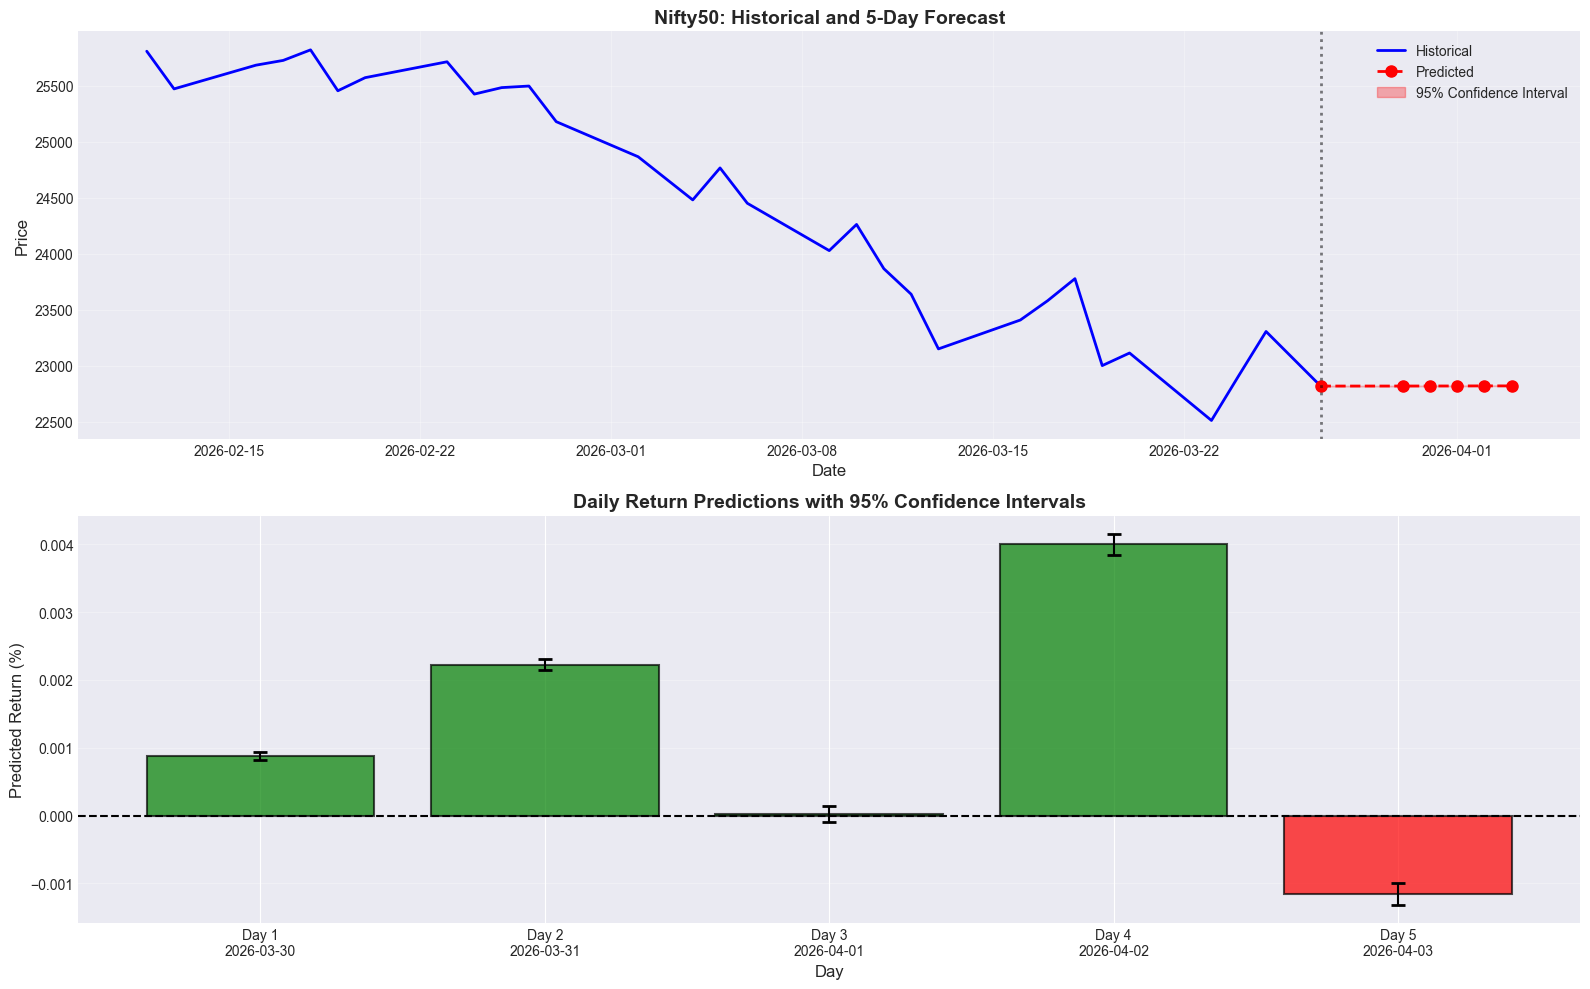

In [20]:
# Visualize next 5 days predictions
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Historical + Predicted
historical_dates = df_features.index[-30:]
historical_prices = df['close'].iloc[-30:]

all_dates = list(historical_dates) + list(future_dates)
predicted_prices = [df['close'].iloc[-1]]
for pred in next_5_predictions:
    predicted_prices.append(predicted_prices[-1] * (1 + pred/100))

axes[0].plot(historical_dates, historical_prices, 'b-', linewidth=2, label='Historical')
axes[0].plot([historical_dates[-1]] + list(future_dates), predicted_prices, 
            'r--', linewidth=2, marker='o', markersize=8, label='Predicted')

# Add confidence intervals
ci_prices_lower = [df['close'].iloc[-1]]
ci_prices_upper = [df['close'].iloc[-1]]
for (ci_low, ci_up) in next_5_ci:
    ci_prices_lower.append(ci_prices_lower[-1] * (1 + ci_low/100))
    ci_prices_upper.append(ci_prices_upper[-1] * (1 + ci_up/100))

axes[0].fill_between([historical_dates[-1]] + list(future_dates), 
                     ci_prices_lower, ci_prices_upper, alpha=0.3, color='red', 
                     label='95% Confidence Interval')

axes[0].axvline(historical_dates[-1], color='black', linestyle=':', linewidth=2, alpha=0.5)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].set_title('Nifty50: Historical and 5-Day Forecast', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Daily returns prediction
axes[1].bar(range(1, 6), next_5_predictions, color=['green' if p > 0 else 'red' for p in next_5_predictions],
           alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].errorbar(range(1, 6), next_5_predictions, 
                yerr=[[p - ci[0] for p, ci in zip(next_5_predictions, next_5_ci)],
                      [ci[1] - p for p, ci in zip(next_5_predictions, next_5_ci)]],
                fmt='none', ecolor='black', capsize=5, capthick=2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Day', fontsize=12)
axes[1].set_ylabel('Predicted Return (%)', fontsize=12)
axes[1].set_title('Daily Return Predictions with 95% Confidence Intervals', fontweight='bold', fontsize=14)
axes[1].set_xticks(range(1, 6))
axes[1].set_xticklabels([f'Day {i}\n{date.strftime("%Y-%m-%d")}' for i, date in enumerate(future_dates, 1)])
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. Sector Analysis and Investment Recommendations

In [21]:
# Analyze sector performance using recent data
sectors = ['bank', 'it', 'pharma', 'auto', 'fmcg', 'metal', 'energy']
sector_columns = [f'{s}_ret' for s in sectors]

# Get latest sector data
recent_data = df_features.tail(30)

# Calculate sector statistics
sector_stats = pd.DataFrame({
    'Sector': [s.upper() for s in sectors],
    'Recent_Avg_Return': [recent_data[f'{s}_ret'].mean() * 100 for s in sectors],
    'Volatility': [recent_data[f'{s}_ret'].std() * 100 for s in sectors],
    'Sharpe': [recent_data[f'{s}_ret'].mean() / (recent_data[f'{s}_ret'].std() + 1e-10) for s in sectors],
    'Correlation_with_Nifty': [recent_data[f'{s}_ret'].corr(recent_data['log_ret']) for s in sectors],
    'Latest_Return': [df_features[f'{s}_ret'].iloc[-1] * 100 for s in sectors]
})

sector_stats = sector_stats.sort_values('Recent_Avg_Return', ascending=False)

print("="*80)
print("SECTOR PERFORMANCE ANALYSIS (Last 30 Days)")
print("="*80)
print(sector_stats.to_string(index=False))

# Sector recommendation based on multiple factors
print("\n" + "="*80)
print("INVESTMENT RECOMMENDATIONS")
print("="*80)

# Score each sector
sector_stats['Score'] = (
    sector_stats['Recent_Avg_Return'].rank() * 0.4 +
    sector_stats['Sharpe'].rank() * 0.3 +
    sector_stats['Latest_Return'].rank() * 0.2 -
    sector_stats['Volatility'].rank() * 0.1
)

sector_stats = sector_stats.sort_values('Score', ascending=False)

print("\nSector Rankings (Higher Score = Better Investment Opportunity):")
print("\n" + sector_stats[['Sector', 'Recent_Avg_Return', 'Sharpe', 'Volatility', 'Score']].to_string(index=False))

# Top 3 sectors
top_sectors = sector_stats.head(3)

print("\n" + "="*80)
print("TOP 3 SECTORS FOR INVESTMENT (Next 5 Days)")
print("="*80)

for idx, (_, row) in enumerate(top_sectors.iterrows(), 1):
    print(f"\n{idx}. {row['Sector']}")
    print(f"   Recent Average Return: {row['Recent_Avg_Return']:+.4f}%")
    print(f"   Risk-Adjusted Return (Sharpe): {row['Sharpe']:.4f}")
    print(f"   Volatility: {row['Volatility']:.4f}%")
    print(f"   Latest Return: {row['Latest_Return']:+.4f}%")
    print(f"   Investment Score: {row['Score']:.2f}")
    
    # Recommendation
    if row['Recent_Avg_Return'] > 0.5:
        recommendation = "STRONG BUY - High positive momentum"
    elif row['Recent_Avg_Return'] > 0.2:
        recommendation = "BUY - Positive momentum"
    elif row['Recent_Avg_Return'] > 0:
        recommendation = "HOLD - Weak positive momentum"
    else:
        recommendation = "AVOID - Negative momentum"
    
    print(f"   Recommendation: {recommendation}")

SECTOR PERFORMANCE ANALYSIS (Last 30 Days)
Sector  Recent_Avg_Return  Volatility    Sharpe  Correlation_with_Nifty  Latest_Return
PHARMA           0.026073    1.168026  0.022323                0.743534      -0.503314
ENERGY          -0.124842    1.352723 -0.092290                0.707085      -0.960862
 METAL          -0.293927    2.164836 -0.135774                0.802253      -1.591841
  FMCG          -0.379411    1.237287 -0.306647                0.862549      -1.810685
  BANK          -0.486288    1.637072 -0.297047                0.958635      -2.669057
  AUTO          -0.503807    2.202665 -0.228726                0.919125      -2.819992
    IT          -0.557530    1.749059 -0.318760                0.399051      -0.436956

INVESTMENT RECOMMENDATIONS

Sector Rankings (Higher Score = Better Investment Opportunity):

Sector  Recent_Avg_Return    Sharpe  Volatility  Score
PHARMA           0.026073  0.022323    1.168026    6.0
ENERGY          -0.124842 -0.092290    1.352723    4.9
 M

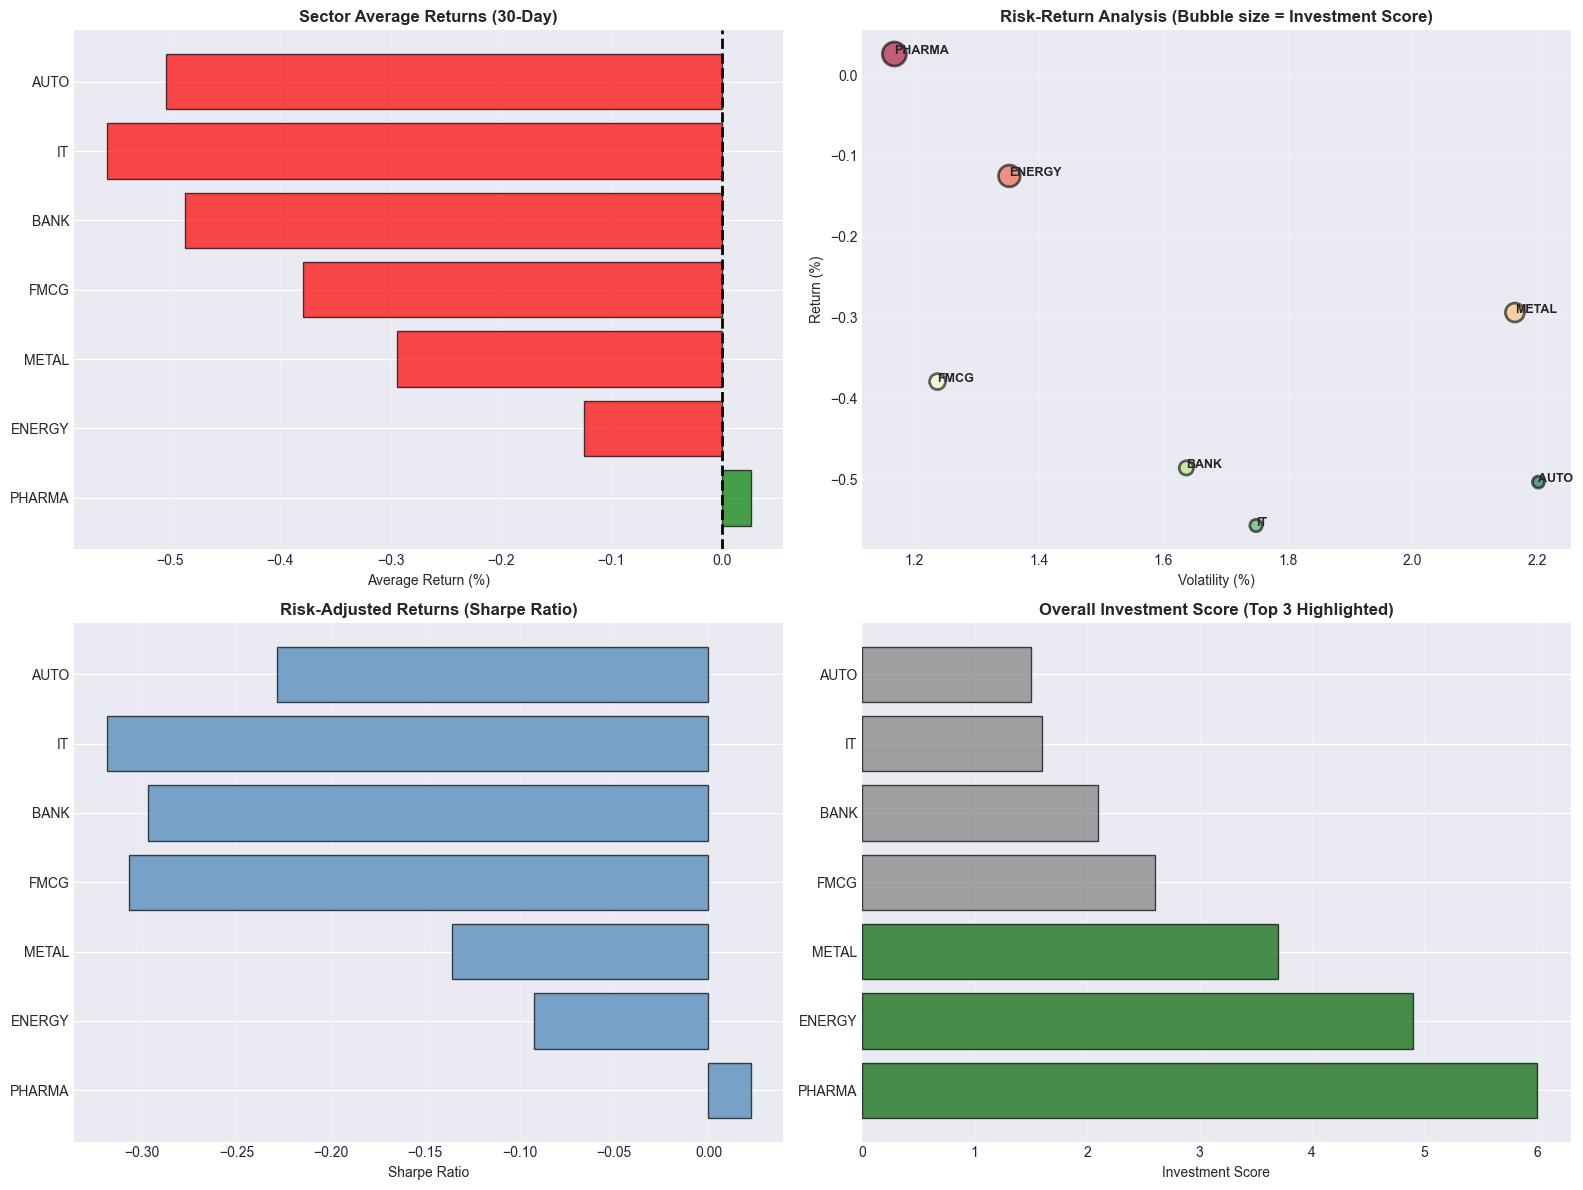

In [22]:
# Sector visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sector returns
axes[0, 0].barh(sector_stats['Sector'], sector_stats['Recent_Avg_Return'], 
               color=['green' if r > 0 else 'red' for r in sector_stats['Recent_Avg_Return']],
               alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Average Return (%)')
axes[0, 0].set_title('Sector Average Returns (30-Day)', fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# Risk-Return scatter
scatter = axes[0, 1].scatter(sector_stats['Volatility'], sector_stats['Recent_Avg_Return'], 
                            s=sector_stats['Score']*50, alpha=0.6, c=range(len(sector_stats)),
                            cmap='RdYlGn', edgecolor='black', linewidth=2)
for idx, row in sector_stats.iterrows():
    axes[0, 1].annotate(row['Sector'], (row['Volatility'], row['Recent_Avg_Return']),
                       fontsize=9, fontweight='bold')
axes[0, 1].set_xlabel('Volatility (%)')
axes[0, 1].set_ylabel('Return (%)')
axes[0, 1].set_title('Risk-Return Analysis (Bubble size = Investment Score)', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Sharpe ratio
axes[1, 0].barh(sector_stats['Sector'], sector_stats['Sharpe'], 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Sharpe Ratio')
axes[1, 0].set_title('Risk-Adjusted Returns (Sharpe Ratio)', fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# Investment scores
axes[1, 1].barh(sector_stats['Sector'], sector_stats['Score'], 
               color=['darkgreen' if i < 3 else 'gray' for i in range(len(sector_stats))],
               alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Investment Score')
axes[1, 1].set_title('Overall Investment Score (Top 3 Highlighted)', fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

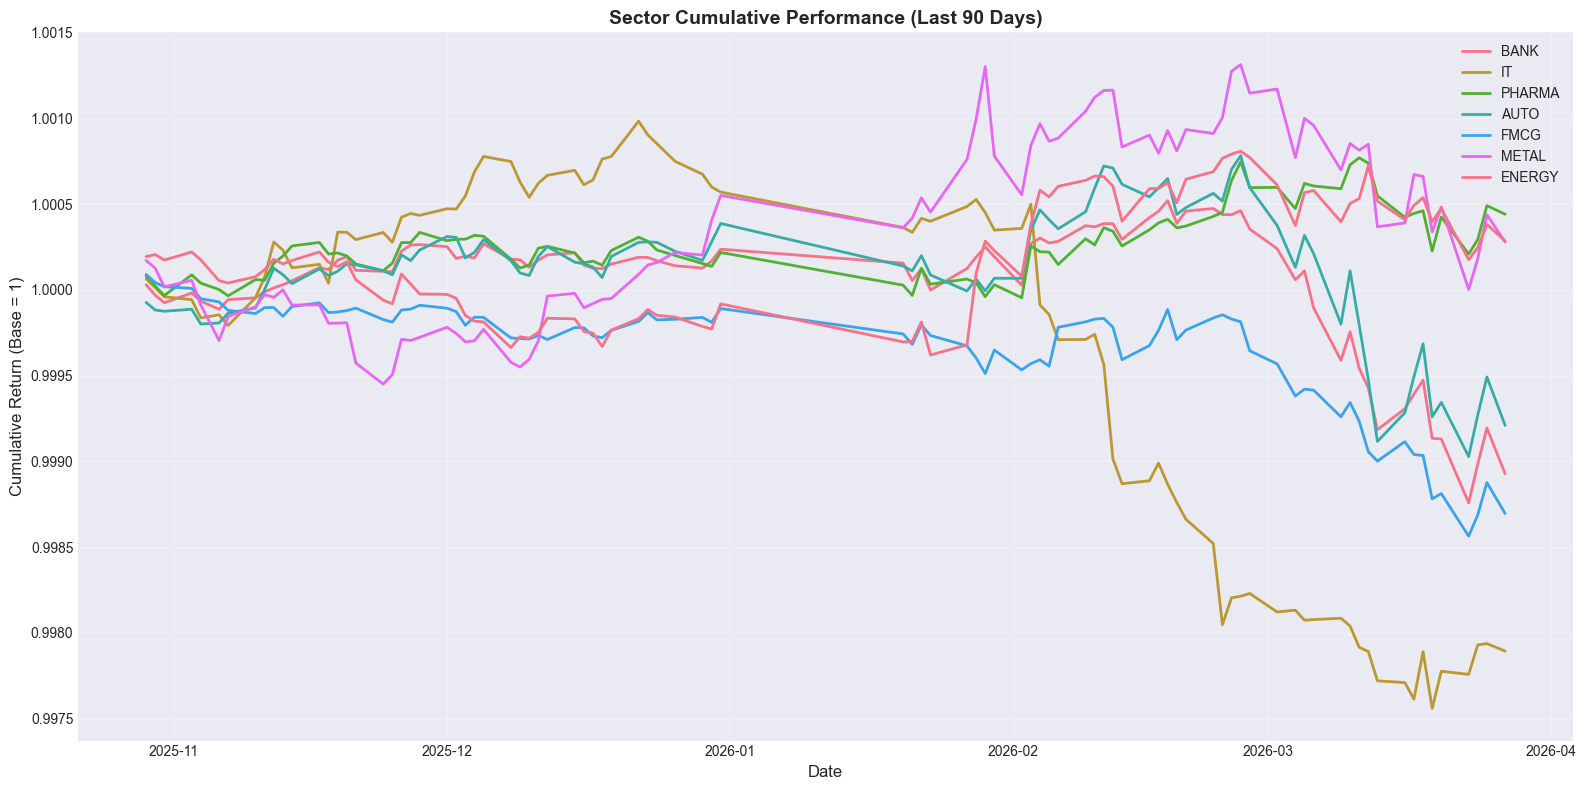

In [23]:
# Historical sector performance
fig, ax = plt.subplots(figsize=(16, 8))

for sector in sectors:
    sector_cumret = (1 + df_features[f'{sector}_ret'].tail(90) / 100).cumprod()
    ax.plot(df_features.tail(90).index, sector_cumret, linewidth=2, label=sector.upper())

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Base = 1)', fontsize=12)
ax.set_title('Sector Cumulative Performance (Last 90 Days)', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Key Insights and Model Parameters Summary

In [24]:
print("=" * 80)
print("FINAL SUMMARY: POINT FORECASTING WITH SimpleRNN")
print("=" * 80)

print("\n1. OPTIMAL MODEL CONFIGURATION:")
print("-" * 80)
print(f"   Architecture           : SimpleRNN (2 stacked layers)")
print(f"   Window Size            : {best_config['window_size']} days")
print(f"   RNN Units              : {best_config['units']}")
print(f"   Dropout Rate           : {best_config['dropout']}")
print(f"   Learning Rate          : {best_config['learning_rate']}")
print(f"   Batch Size             : {best_config['batch_size']}")
print(f"   Total Parameters       : {best_model.count_params():,}")

print("\n2. PERFORMANCE METRICS:")
print("-" * 80)
print(f"   Root Mean Squared Error (RMSE) : {best_result['RMSE']:.6f}")
print(f"   Mean Absolute Error (MAE)      : {best_result['MAE']:.6f}")
print(f"   R² Score                       : {best_result['R2']:.6f}")
print(f"   Direction Accuracy             : {best_result['dir_accuracy']*100:.2f}%")
print(f"   Sharpe Ratio (Trading Sim)     : {sharpe_ratio:.4f}")

print("\n3. FEATURE IMPORTANCE:")
print("-" * 80)
print(f"   Total Features Used: {len(selected_features)}")
print(f"   Top Correlated Features:")
for i, (feature, corr) in enumerate(target_corr[1:6].items(), 1):
    print(f"      {i}. {feature}: {correlation_matrix['target'][feature]:.4f}")

print("\n4. NEXT 5 DAYS FORECAST:")
print("-" * 80)
for i, (date, pred) in enumerate(zip(future_dates, next_5_predictions), 1):
    trend = '↑' if pred > 0 else '↓'
    print(f"   Day {i} ({date.strftime('%Y-%m-%d')}): {pred:+.4f}% {trend}")
print(f"   5-Day Cumulative Return: {cumulative_return:+.4f}%")

print("\n5. INVESTMENT RECOMMENDATIONS:")
print("-" * 80)
for idx2, (_, row) in enumerate(top_sectors.iterrows(), 1):
    print(f"   {idx2}. {row['Sector']}: Score {row['Score']:.2f},"
          f" Avg Return {row['Recent_Avg_Return']:+.4f}%")

print("\n6. MODEL CONFIDENCE:")
print("-" * 80)
avg_ci_width = np.mean([ci[1] - ci[0] for ci in next_5_ci])
print(f"   Avg 95% CI Width : ±{avg_ci_width/2:.4f}%")
print(f"   Model Confidence : {'High' if avg_ci_width < 1.0 else 'Moderate' if avg_ci_width < 2.0 else 'Low'}")

print("\n" + "=" * 80)
print("DISCLAIMER: These predictions are based on historical data and should not")
print("be the sole basis for investment decisions. Always consult a qualified")
print("financial advisor before making investments.")
print("=" * 80)

FINAL SUMMARY: POINT FORECASTING WITH SimpleRNN

1. OPTIMAL MODEL CONFIGURATION:
--------------------------------------------------------------------------------
   Architecture           : SimpleRNN (2 stacked layers)
   Window Size            : 5 days
   RNN Units              : 32
   Dropout Rate           : 0.3
   Learning Rate          : 0.0005
   Batch Size             : 32
   Total Parameters       : 4,209

2. PERFORMANCE METRICS:
--------------------------------------------------------------------------------
   Root Mean Squared Error (RMSE) : 0.008316
   Mean Absolute Error (MAE)      : 0.006168
   R² Score                       : -0.017708
   Direction Accuracy             : 48.22%
   Sharpe Ratio (Trading Sim)     : 0.0205

3. FEATURE IMPORTANCE:
--------------------------------------------------------------------------------
   Total Features Used: 50
   Top Correlated Features:
      1. energy_ret: -0.0911
      2. fmcg_ret_lag2: 0.0802
      3. metal_ret: -0.0698
      4

In [25]:
# Save best model
best_model.save('/home/claude/best_rnn_point_forecast_model.h5')
print("\nBest model saved to: /home/claude/best_rnn_point_forecast_model.h5")

# Save results to CSV
results_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Return_%': next_5_predictions,
    'CI_Lower_%': [ci[0] for ci in next_5_ci],
    'CI_Upper_%': [ci[1] for ci in next_5_ci]
})
results_df.to_csv('/home/claude/next_5_days_predictions.csv', index=False)
print("Predictions saved to: /home/claude/next_5_days_predictions.csv")


Best model saved to: /home/claude/best_rnn_point_forecast_model.h5
Predictions saved to: /home/claude/next_5_days_predictions.csv
